In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
# ds['ID'].value_counts

In [3]:
15*60*24

21600

In [4]:
# import pickle
ds = pd.read_pickle('/kaggle/input/sleep-cleaned-data/martian_bow_shock_dataset.pkl')
events = pd.read_csv('/kaggle/input/sleep-cleaned-data/martian_bow_shock_events.csv')

ds['step'] = ds.groupby(pd.Grouper(freq="D")).cumcount()
# ds['ID'] = ds.groupby(pd.Grouper(freq="D")).grouper.group_info[0]
ds['ID'] = ds.index.dayofyear - 1

events['events'] = pd.to_datetime(events['events'])
events['step'] = ((events['events'].dt.hour * 3600 + events['events'].dt.minute * 60 + events['events'].dt.second - 2) / 4 ).round().astype(int)
events = events.drop_duplicates(subset = ['step'])
events['ID'] = events['events'].dt.dayofyear - 1

ds[['ws_totels_1_new','ws_totels_8','ws_totels_6','ws_rho']] = ds[['ws_totels_1_new','ws_totels_8','ws_totels_6','ws_rho']].fillna(0)
ds = ds.reset_index(drop=True)
ds

,ws_totels_1_new,ws_totels_8,ws_totels_6,ws_rho,step,ID
0,0.0,0.0,0.0,2.064453,0,0
1,0.0,0.0,0.0,2.064453,1,0
2,0.0,0.0,0.0,2.064453,2,0
3,0.0,0.0,0.0,2.064453,3,0
4,0.0,0.0,0.0,2.064453,4,0
...,...,...,...,...,...,...
7905595,0.0,0.0,0.0,4.039062,21595,365
7905596,0.0,0.0,0.0,4.039062,21596,365
7905597,0.0,0.0,0.0,4.039062,21597,365
7905598,0.0,0.0,0.0,4.039062,21598,365


In [5]:
ds.describe()

/opt/conda/lib/python3.10/site-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/opt/conda/lib/python3.10/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/opt/conda/lib/python3.10/site-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/opt/conda/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)
/opt/conda/lib/python3.10/site-packages/pandas/core/nanops.py:1019: RuntimeWarning: invalid value encountered in scalar divide
  result = sqr.sum(axis=axis, dtype=np.float64) / d
/opt/conda/lib/python3.10/site-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/opt/conda/lib/python3.10/site-

,ws_totels_1_new,ws_totels_8,ws_totels_6,ws_rho,step,ID
count,7905600.0,7905600.0,7905600.0,7.905600e+06,7.905600e+06,7.905600e+06
mean,NaN,NaN,NaN,NaN,1.079950e+04,1.825000e+02
std,NaN,NaN,NaN,0.000000e+00,6.235383e+03,1.056547e+02
min,0.0,-41344.0,-5580.0,2.122879e-03,0.000000e+00,0.000000e+00
25%,0.0,0.0,0.0,1.730469e+00,5.399750e+03,9.100000e+01
50%,0.0,0.0,0.0,2.925781e+00,1.079950e+04,1.825000e+02
75%,473.0,0.0,0.0,3.625000e+00,1.619925e+04,2.740000e+02
max,65504.0,65472.0,8392.0,4.105469e+00,2.159900e+04,3.650000e+02


In [6]:
len(ds) / len(events)

4808.759124087591

In [7]:
# pd.read_parquet('/kaggle/input/child-mind-institute-detect-sleep-states/train_series.parquet')

In [8]:
orange_black = [
    '#fdc029', '#df861d', '#FF6347', '#aa3d01', '#a30e15', '#800000', '#171820'
]
# Setting plot styling.
# plt.style.use('ggplot')
# plt.rcParams["font.size"] = 1000
plt.style.use(("seaborn-paper"))
plt.rcParams.update({'font.size': 15,
                     'xtick.labelsize' : 15,
                     'ytick.labelsize' : 15,
                     'axes.labelsize': 15,
                     'axes.titlesize': 15})

# plt.rcParams['figure.figsize'] = (18, 14)
# plt.rcParams['figure.dpi'] = 100
# plt.rcParams["axes.grid"] = True
# plt.rcParams["grid.color"] = orange_black[-1]
# plt.rcParams["grid.alpha"] = 1.0
# plt.rcParams["grid.linestyle"] = '--'
# plt.rcParams["font.family"] = "Times New Roman"
# plt.rcParams["text.color"] = 'black'

# plt.rcParams['axes.edgecolor'] = orange_black[0]
# plt.rcParams['figure.frameon'] = False
# plt.rcParams['axes.spines.left'] = True
# plt.rcParams['axes.spines.bottom'] = True
# plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.spines.right'] = False
# plt.rcParams['axes.linewidth'] = 1.0

/tmp/ipykernel_18/2152133413.py:7: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use(("seaborn-paper"))


In [9]:
from math import pi, sqrt, exp

# sigma = 50

def get_targets(X, y, ttype = 'gau', sigma=50, ):
    r = range(-int(sigma*3),int(sigma*3)+1)
    gauss = np.array([exp((-float(x/sigma)**2)/2) for x in r])
    
    target_guassian = np.zeros((len(X),2))
    
    if ttype == 'hard':
        for s,e in y:
            target_guassian[s,0] = 1
            target_guassian[e,1] = 1
    elif ttype=='gau':
        for s,e in y:
#             print(s,e)
            st1,st2 = max(0,s-sigma*3),s+sigma*3+1
            ed1,ed2 = e-sigma*3,min(len(X),e+sigma*3+1)
            target_guassian[st1:st2,0] = gauss[st1-(s-sigma*3):]
            target_guassian[ed1:ed2,1] = gauss[:sigma*6+1-((e+sigma*3+1)-ed2)]
    elif ttype == 'custom':
        for s,e in y:
            for w in [12, 36, 60, 90, 120, 150, 180, 240, 300, 360]:
                st1,st2 = max(0,s-w),s+w+1
                ed1,ed2 = e-w,min(len(X),e+w+1)
                target_guassian[st1:st2,0] += 1
                target_guassian[ed1:ed2,1] += 1
            target_guassian /= 10
        
    return target_guassian

In [10]:

# # Fixing random state for reproducibility
# np.random.seed(19680801)


# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')
# ax.view_init(elev=20., azim=120)

# colors = ['r', 'g', 'b', 'y']
# yticks = [0,1,2]


# state_orig = np.array([0.5]* 1000 + [1]*1000 + [0.5]*1000)
# y = [[1000, 2000]]
# out = get_targets(state_orig, y, 100)
# target0,target1 = out[:,0], out[:,1]

# k = 0
# for k in range(3):
#     xs = np.arange(len(state_orig))
#     ys = [target0,target1,state_orig,][k]
#     c = colors[k]
#     cs = [c] * len(xs)
# #     ax.bar(xs, k, zs=ys, zdir='z',bottom = -1,  color=cs, alpha=0.8)
#     ax.bar(xs, ys, zs=k, zdir='x', color=cs, alpha=1,align='edge',)

# # ax.set_xlabel('Result')
# ax.set_ylabel('Target')
# ax.set_zlabel('Class')

# ax.set_xticks([0,1,2],['target 0','target 1','original'])
# ax.set_zticks([0])
# ax.set_yticks([0])

# # On the y-axis let's only label the discrete values that we have data for.
# # ax.set_zticks(yticks)

# plt.show()

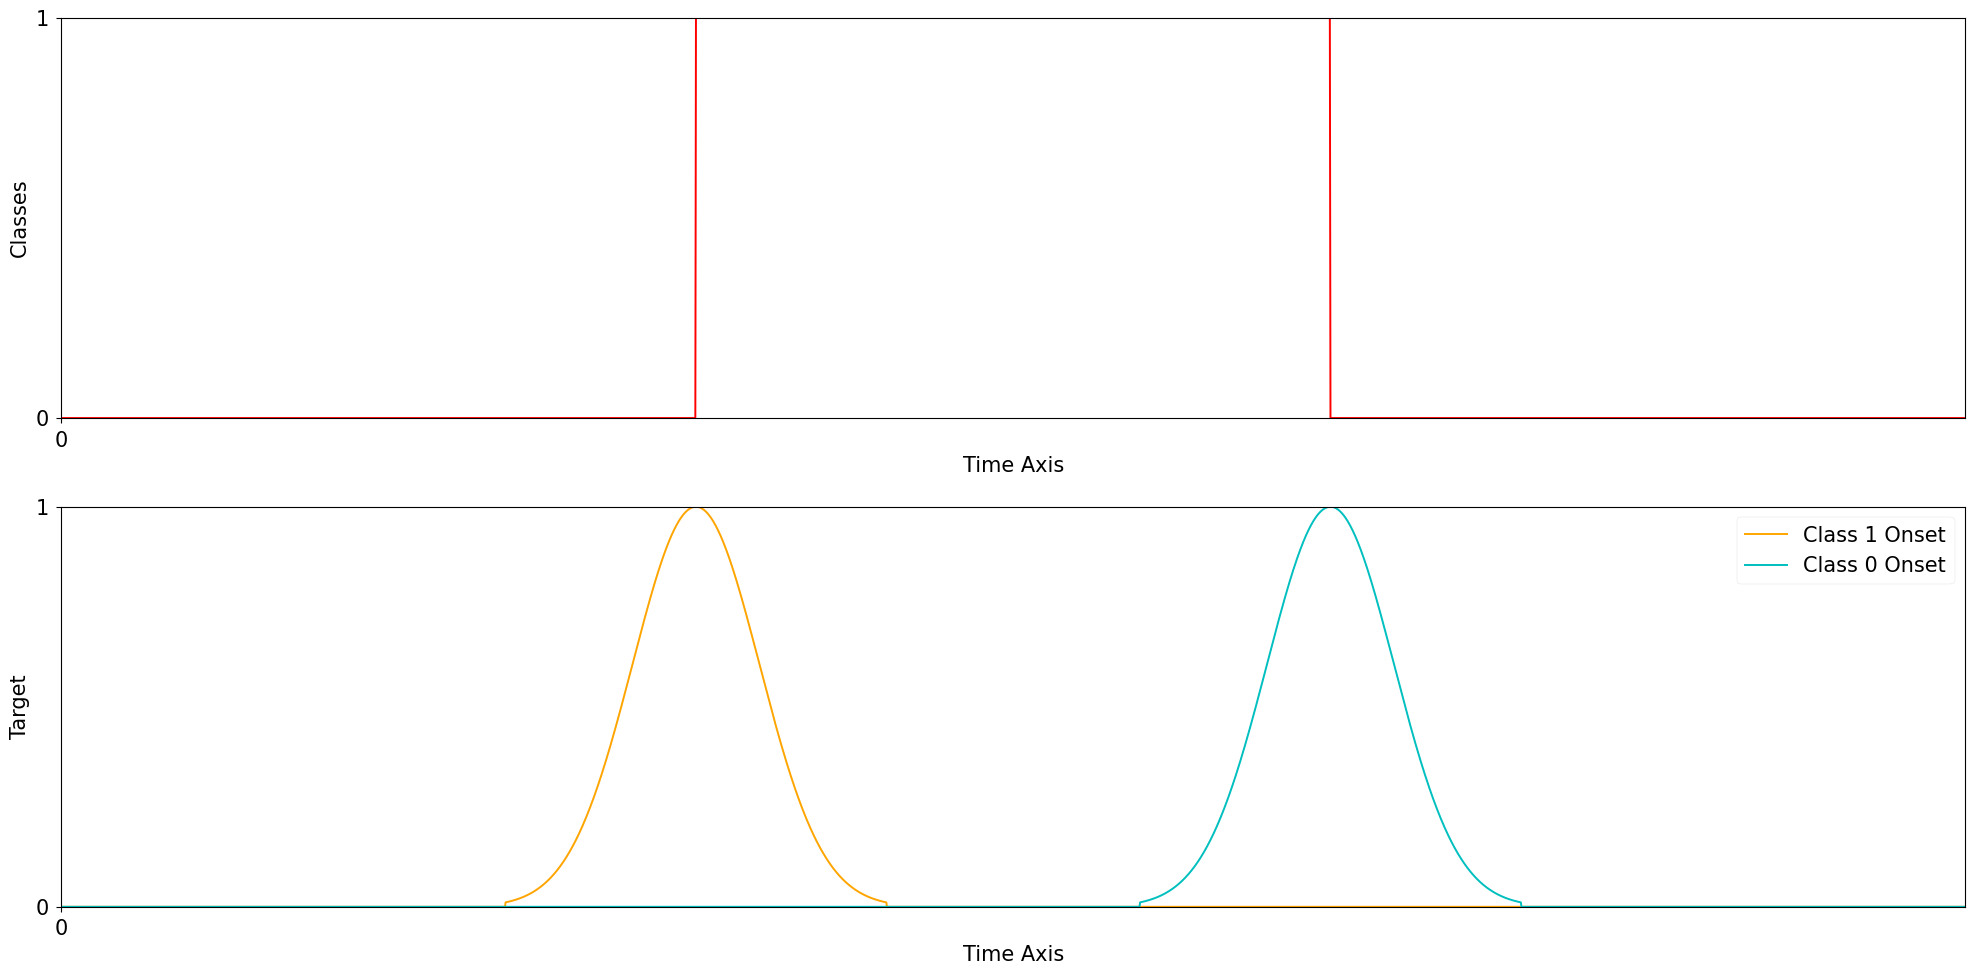

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(19680801)

# fig = plt.figure(figsize=(10, 2), dpi=80)
fig, ax = plt.subplots(2, figsize=(20, 10))

colors = ['r','orange','c', 'y', 'blue', 'y']
yticks = [0,1,2]


state_orig = np.array([0]* 1000 + [1]*1000 + [0]*1000)
y = [[1000, 2000]]
out = get_targets(state_orig, y, 'gau', 100)
target0,target1 = out[:,0], out[:,1]

k = 0
xs = np.arange(len(state_orig))
c = colors[k]
cs = [c] * len(xs)
ax[0].plot(xs, state_orig, c = colors[0])

ax[0].set_xlim((0,int(len(state_orig))))
ax[0].set_ylim((0,1))
            
ax[1].plot(xs, out[:,0], c = colors[1])
ax[1].plot(xs, out[:,1], c = colors[2])

ax[1].set_xlim((0,int(len(state_orig))))
ax[1].set_ylim((0,1))
    

ax[0].set_xlabel('Time Axis')
ax[0].set_xticks([0])
ax[0].set_ylabel('Classes')
ax[0].set_yticks([0,1])

ax[1].set_xlabel('Time Axis')
ax[1].set_ylabel('Target')
ax[1].set_xticks([0])
ax[1].set_yticks([0,1])
ax[1].legend(['Class 1 Onset', 'Class 0 Onset'],prop={'size': 15})

# ax.set_yticks([0,1,2],['target 0','target 1','original'])

# On the y-axis let's only label the discrete values that we have data for.
# ax.set_zticks(yticks)
plt.tight_layout()
plt.savefig('regressiontargetexample')#bbox_inches='tight')
plt.show()

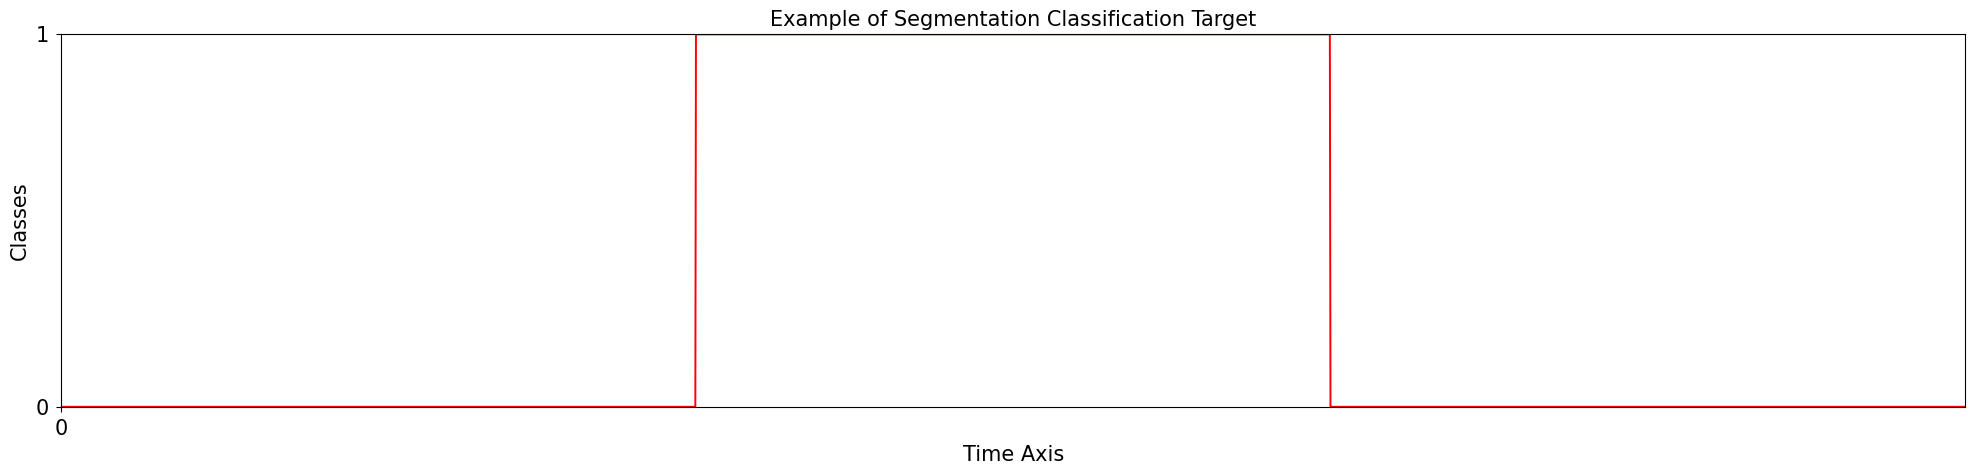

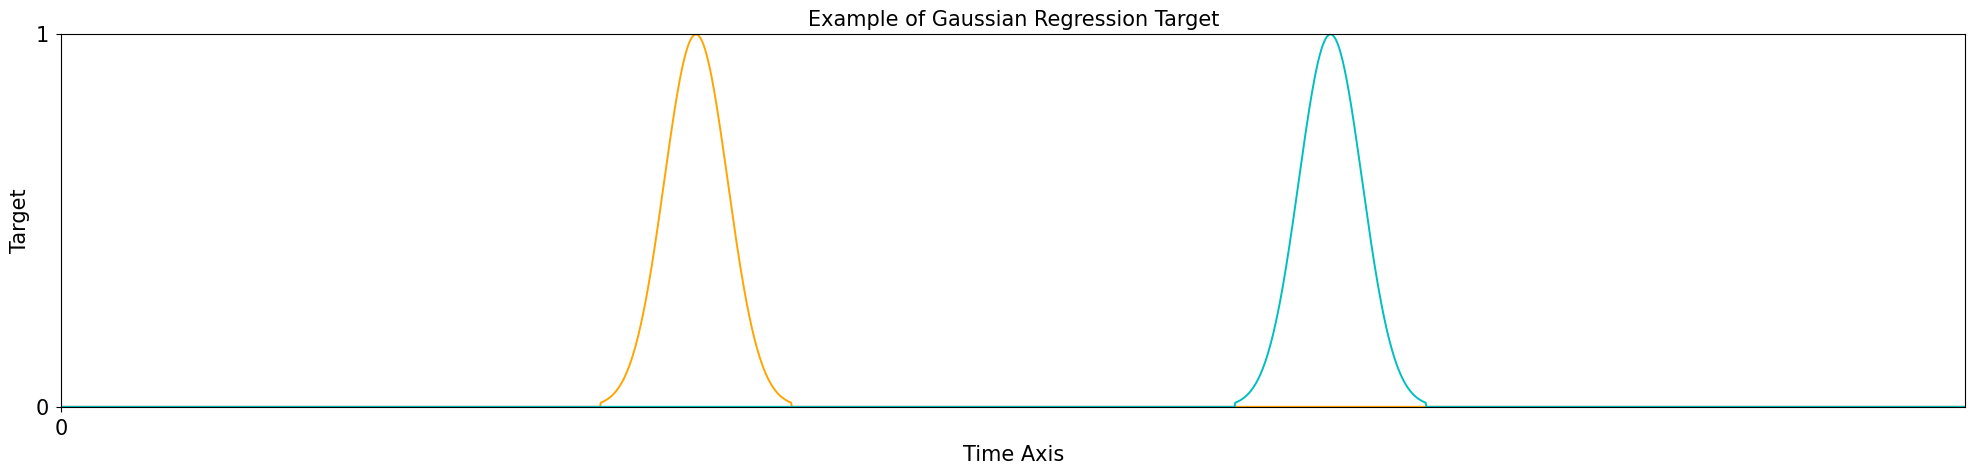

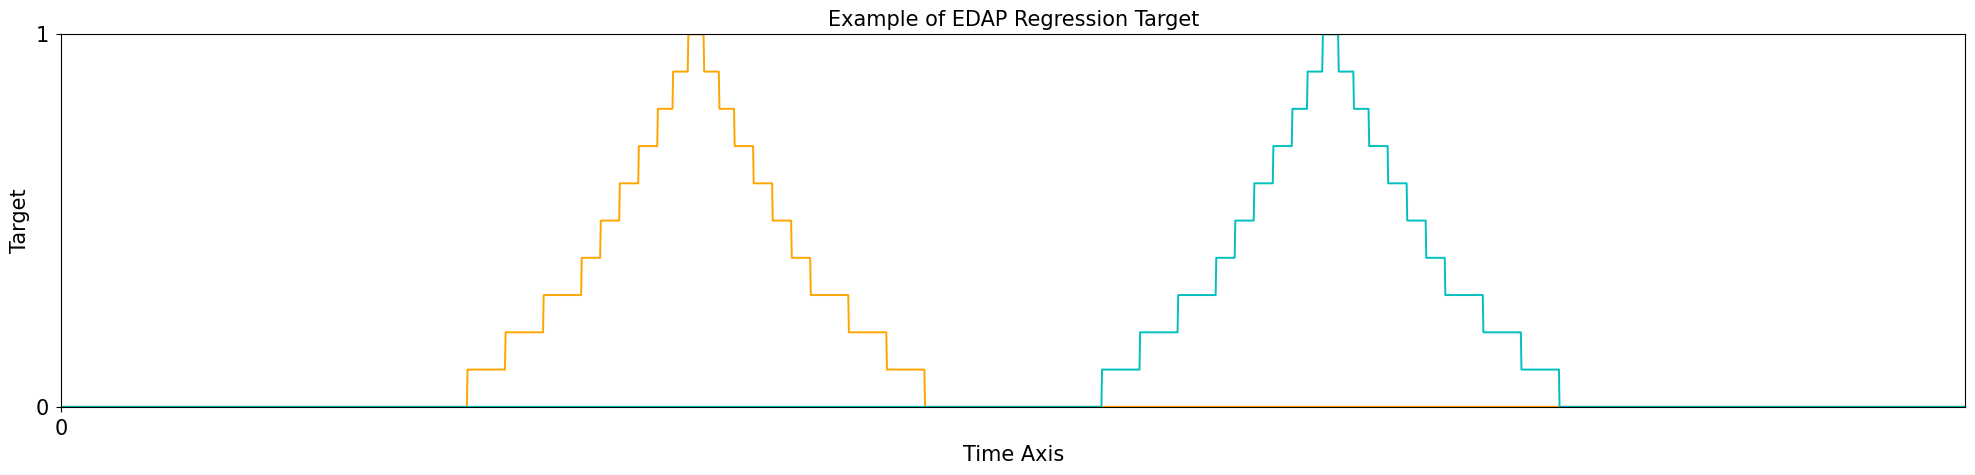

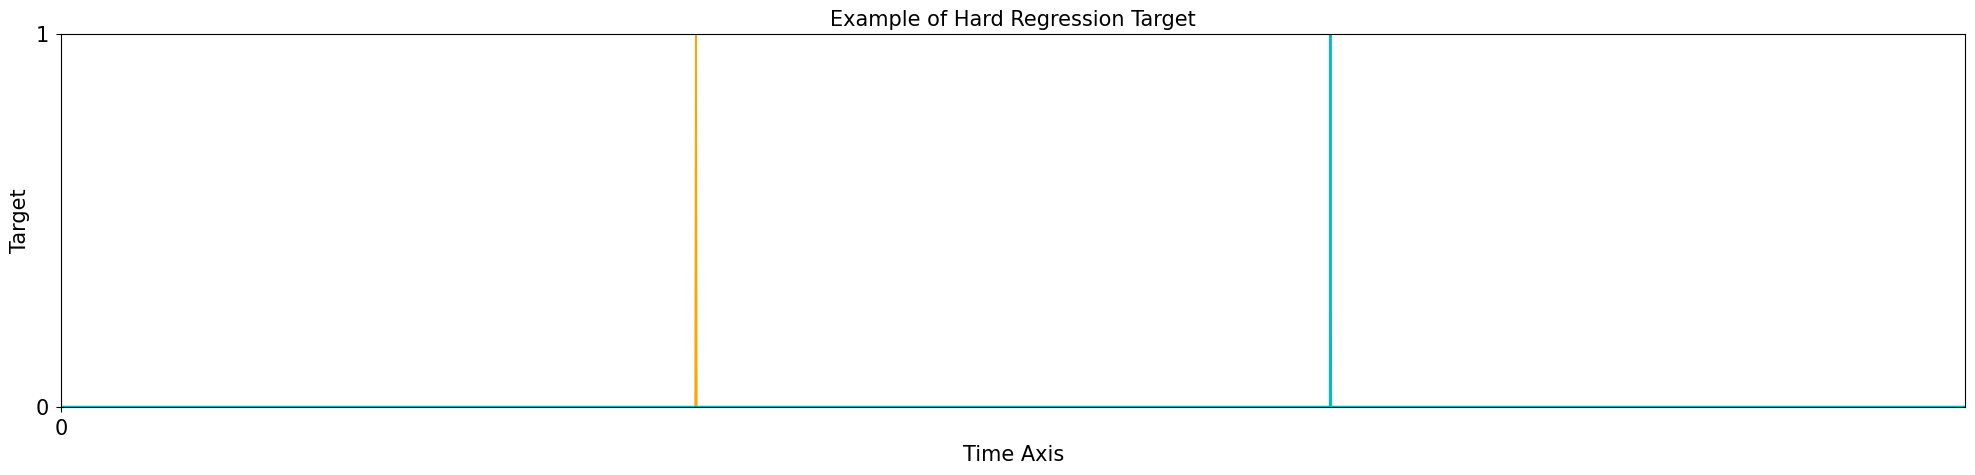

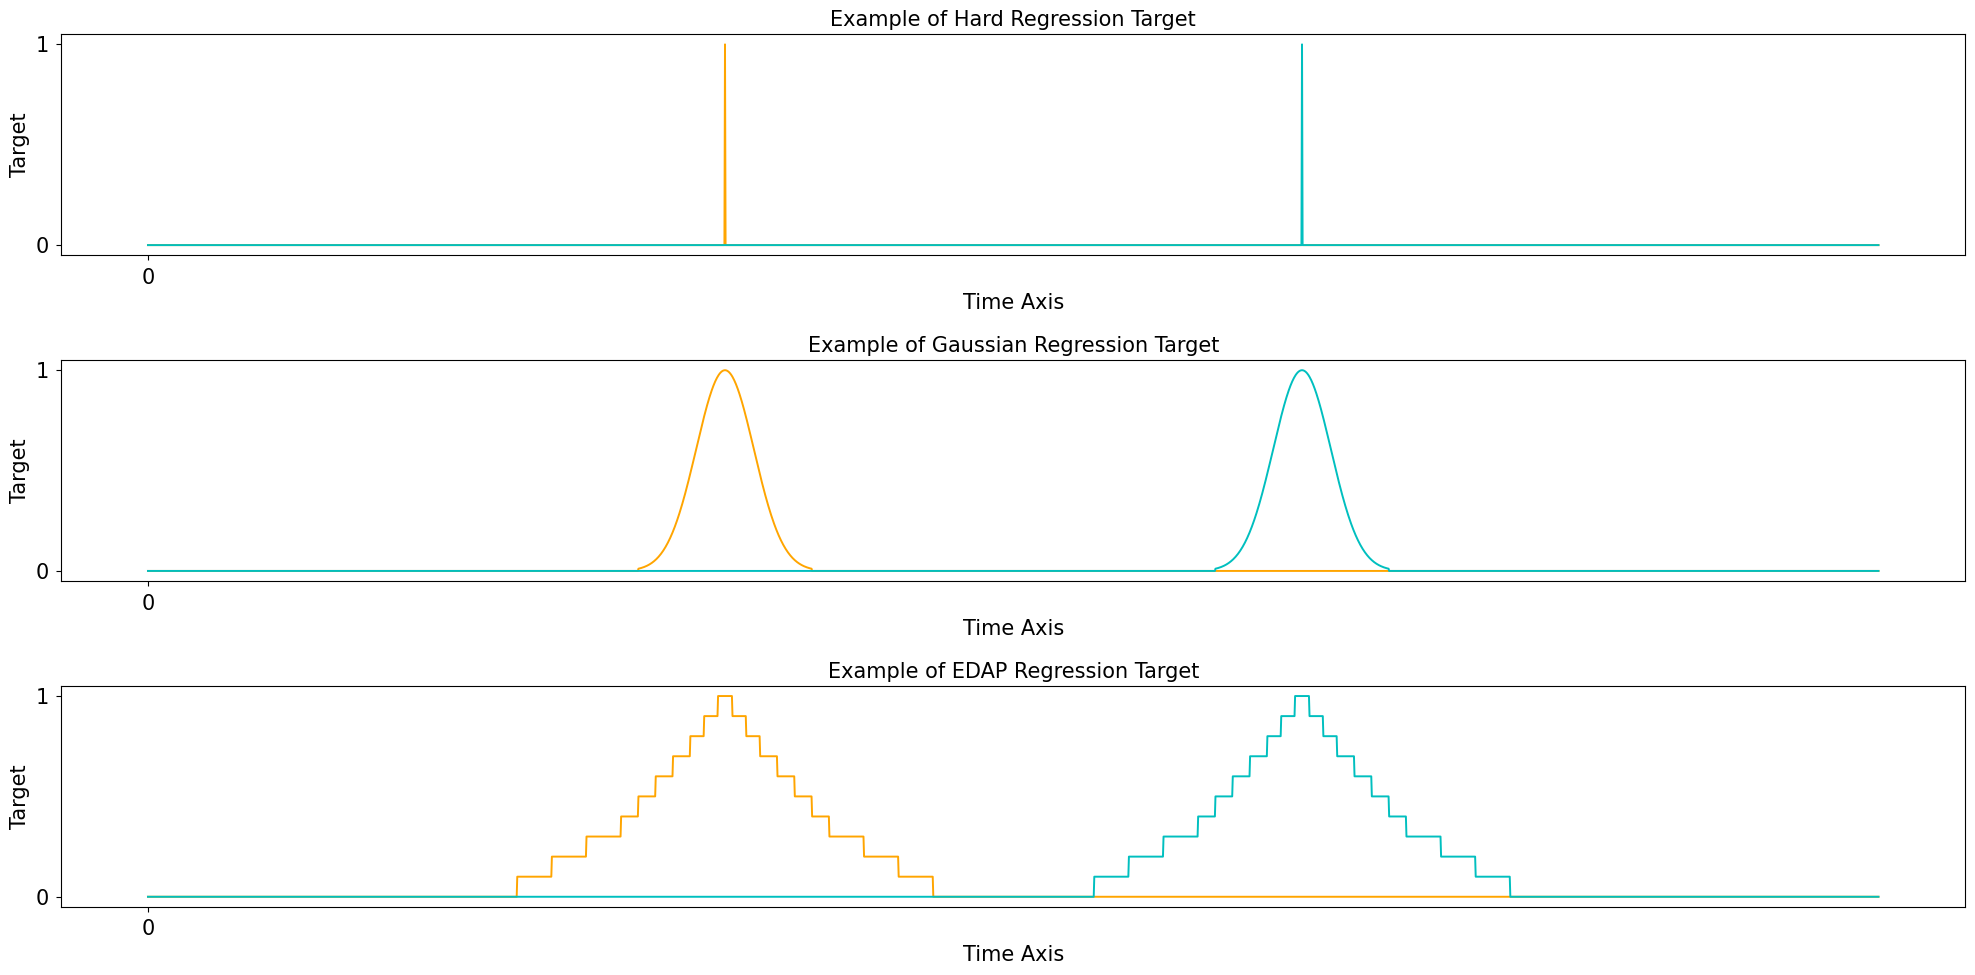

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(19680801)

state_orig = np.array([0]* 1000 + [1]*1000 + [0]*1000)
y = [[1000, 2000]]

fig = plt.figure(figsize=(20, 5))
plt.plot(xs, state_orig, c = colors[0])
plt.xlim((0,int(len(state_orig))))
plt.ylim((0,1))

plt.title('Example of Segmentation Classification Target')
plt.xlabel('Time Axis')
plt.xticks([0])
plt.ylabel('Classes')
plt.yticks([0,1])
plt.tight_layout()
plt.savefig('segmentationtargetexample')#bbox_inches='tight')
plt.show()


out = get_targets(state_orig, y, 'gau')
target0,target1 = out[:,0], out[:,1]

fig = plt.figure(figsize=(20, 5))
plt.plot(xs, out[:,0], c = colors[1])
plt.plot(xs, out[:,1], c = colors[2])
plt.xlim((0,int(len(state_orig))))
plt.ylim((0,1))

plt.title('Example of Gaussian Regression Target')
plt.xlabel('Time Axis')
plt.xticks([0])
plt.ylabel('Target')
plt.yticks([0,1])
plt.tight_layout()
plt.savefig('gauss_regressiontargetexample')#bbox_inches='tight')
plt.show()

out = get_targets(state_orig, y, 'custom')
target0,target1 = out[:,0], out[:,1]

fig = plt.figure(figsize=(20, 5))
plt.plot(xs, out[:,0], c = colors[1])
plt.plot(xs, out[:,1], c = colors[2])
plt.xlim((0,int(len(state_orig))))
plt.ylim((0,1))

plt.title('Example of EDAP Regression Target')
plt.xlabel('Time Axis')
plt.xticks([0])
plt.ylabel('Target')
plt.yticks([0,1])
plt.tight_layout()
plt.savefig('edap_regressiontargetexample')#bbox_inches='tight')
plt.show()


out = get_targets(state_orig, y, 'hard')
target0,target1 = out[:,0], out[:,1]

fig = plt.figure(figsize=(20, 5))
plt.plot(xs, out[:,0], c = colors[1])
plt.plot(xs, out[:,1], c = colors[2])
plt.xlim((0,int(len(state_orig))))
plt.ylim((0,1))

plt.title('Example of Hard Regression Target')#bbox_inches='tight')
plt.xlabel('Time Axis')
plt.xticks([0])
plt.ylabel('Target')
plt.yticks([0,1])
plt.tight_layout()
plt.savefig('hard_regressiontargetexample')
plt.show()

fig, ax = plt.subplots(3, figsize=(20, 10))
i=0
# ax[0].plot(xs, state_orig, c = colors[0])

# ax[0].set_title('Example of Segmentation Classification Target')
# ax[0].set_xlabel('Time Axis')
# ax[0].set_xticks([0])
# ax[0].set_ylabel('Classes')
# ax[0].set_yticks([0,1])

out = get_targets(state_orig, y, 'hard')
target0,target1 = out[:,0], out[:,1]

ax[i].plot(xs, out[:,0], c = colors[1])
ax[i].plot(xs, out[:,1], c = colors[2])
ax[i].set_title('Example of Hard Regression Target')#bbox_inches='tight')
ax[i].set_xlabel('Time Axis')
ax[i].set_xticks([0])
ax[i].set_ylabel('Target')
ax[i].set_yticks([0,1])
i+=1

out = get_targets(state_orig, y, 'gau')
target0,target1 = out[:,0], out[:,1]

ax[i].plot(xs, out[:,0], c = colors[1])
ax[i].plot(xs, out[:,1], c = colors[2])
ax[i].set_title('Example of Gaussian Regression Target')
ax[i].set_xlabel('Time Axis')
ax[i].set_xticks([0])
ax[i].set_ylabel('Target')
ax[i].set_yticks([0,1])
i+=1

out = get_targets(state_orig, y, 'custom')
target0,target1 = out[:,0], out[:,1]

ax[i].plot(xs, out[:,0], c = colors[1])
ax[i].plot(xs, out[:,1], c = colors[2])
ax[i].set_title('Example of EDAP Regression Target')
ax[i].set_xlabel('Time Axis')
ax[i].set_xticks([0])
ax[i].set_ylabel('Target')
ax[i].set_yticks([0,1])
i+=1

plt.tight_layout()
plt.savefig('all_regressiontargetexample')
plt.show()

In [13]:

from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from numba import njit

@njit
def running_score_segmentation(predictions : np.ndarray, interval : int):
    scores = np.zeros(len(predictions), dtype = np.float32)
    
    score_delta_0 = np.sum(predictions[:interval])
    score_delta_1 = np.sum(predictions[interval:2*interval])
    for i in range(interval,len(predictions)-interval):
        scores[i] = (score_delta_1 - score_delta_0)
        
        score_delta_0 = score_delta_0 - predictions[i-interval] + predictions[i]
        score_delta_1 = score_delta_1 - predictions[i]          + predictions[i+interval]
    return scores / interval
def get_candidates(predictions : np.ndarray,
                   objective : str,
                   max_distance : int,
                   day_length : int,
                   threshold : float = 0.002, #between 0 and 1
                   smooth : int = None,
                   ):
    days = len(predictions) // day_length +1
    if smooth:
        for i in range(predictions.shape[1]):
            predictions[:,i] = gaussian_filter1d(predictions[:,i], smooth)
            
            
    if objective[:3] == 'seg':
        if len(objective) == 3 or objective[3] == '1':
            candidates, c_scores = [], []

            events = (predictions[1:] > threshold).astype(int) - (predictions[:-1] > threshold).astype(int)


            locations = np.where(events == 1)[0]
            scores = np.array([abs(np.mean(predictions[max(0,loc-max_distance):loc+1])-
                               np.mean(predictions[loc-1:min(len(predictions),loc+max_distance)])
                              ) for loc in locations])
            candidates.append(locations)
            c_scores.append(scores)


            locations = np.where(events == -1)[0]
            scores = np.array([abs(np.mean(predictions[max(0,loc-max_distance):loc+1])-
                               np.mean(predictions[loc-1:min(len(predictions),loc+max_distance)])
                              ) for loc in locations])
            candidates.append(locations)
            c_scores.append(scores)
            return candidates, c_scores, running_score_segmentation(predictions, max_distance)
        elif objective[3] == '2':
            scores = running_score_segmentation(predictions, max_distance)

            predictions = np.zeros((predictions.shape[0], 2))
            predictions[:,0] = scores
            predictions[:,1] = -scores
        else:
            raise ValueError(f'{objective} not valid')
    else:
        scores = predictions
        
    candidates = []
    c_scores = []
    
    for i in range(predictions.shape[1]):
        
        cand = find_peaks(predictions[:,i], height = threshold, distance = max_distance)[0]
#         print('cand',cand)
        
#         cand = cand[np.argsort(predictions[cand,i])[-2*days:]]

        candidates.append(cand)
        c_scores.append(predictions[cand,i])
    return candidates, c_scores, scores

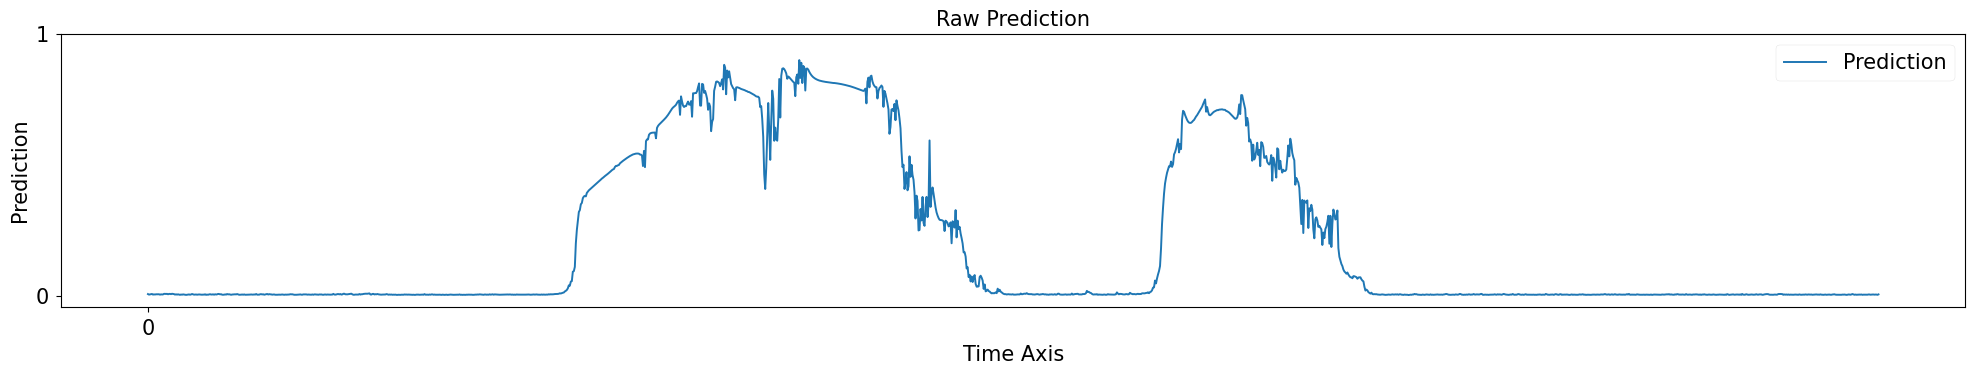

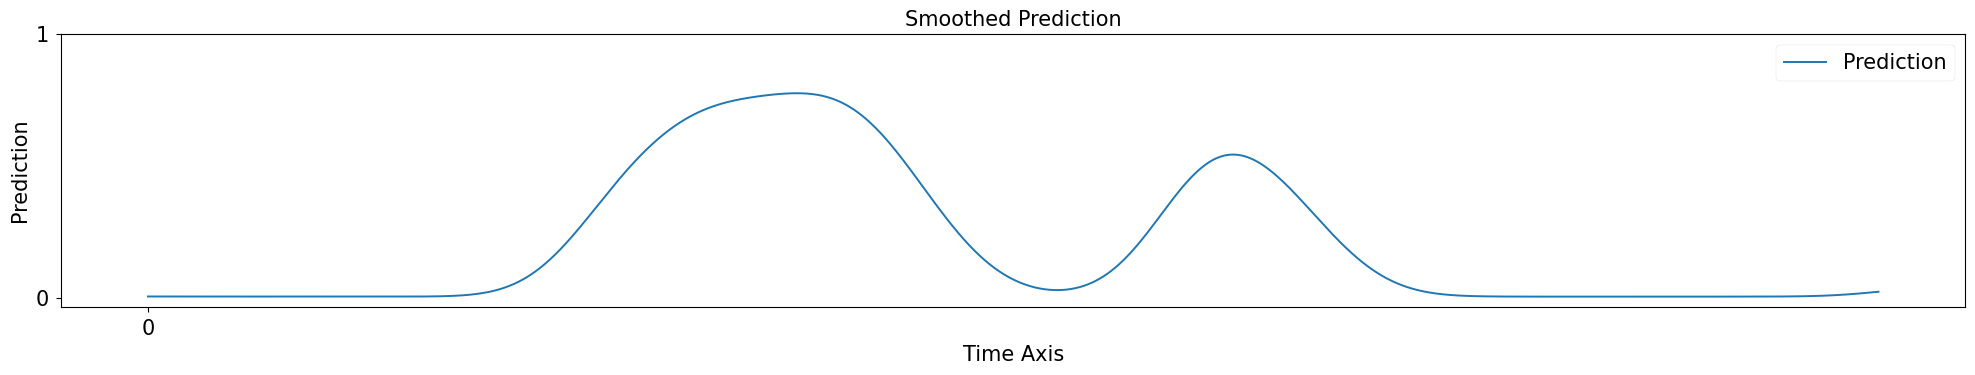

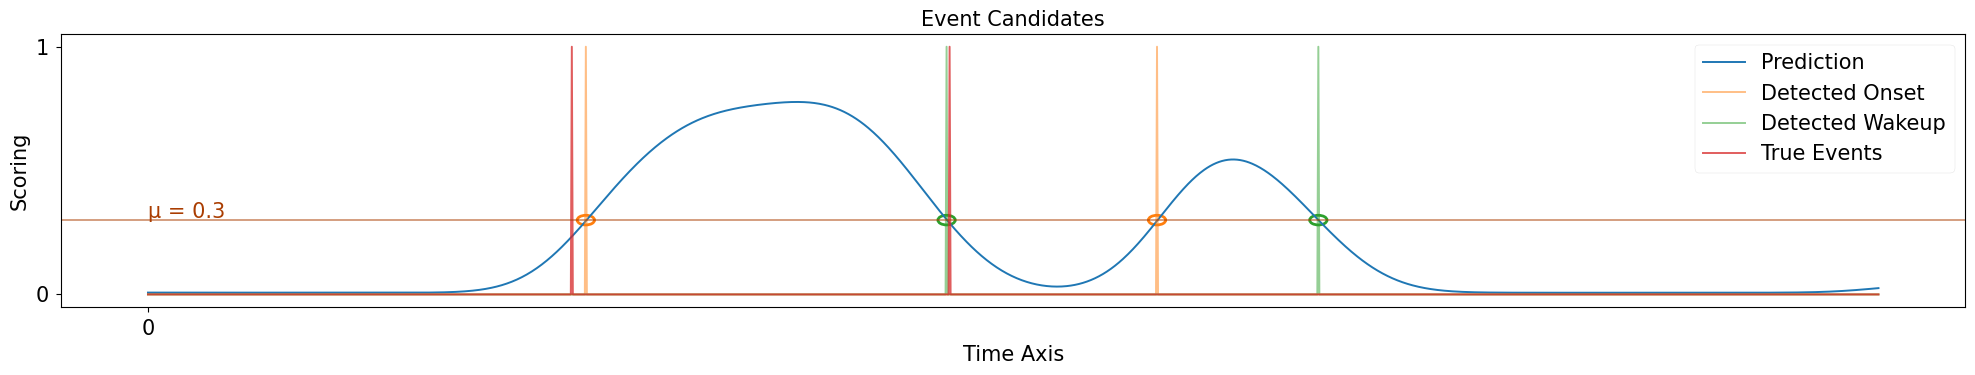

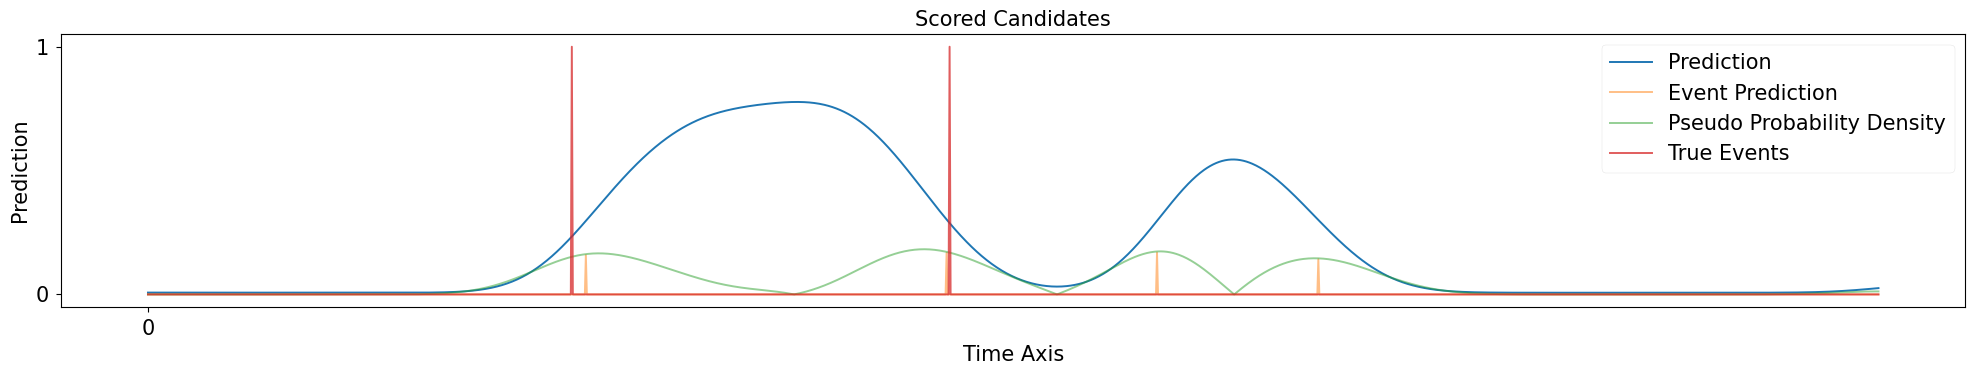

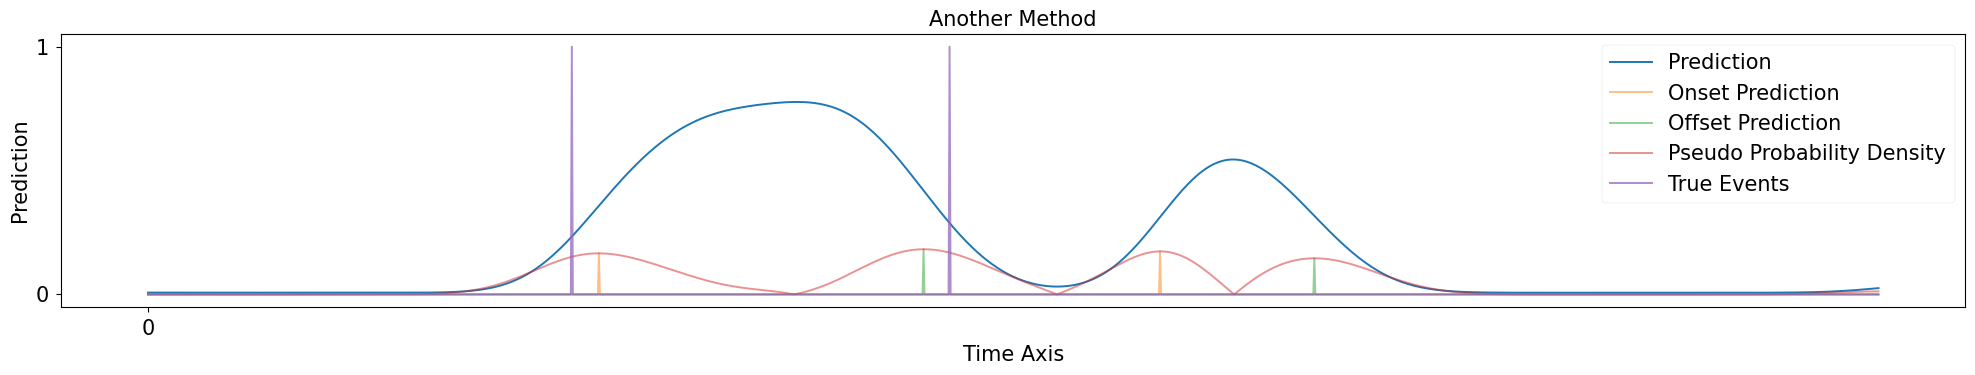

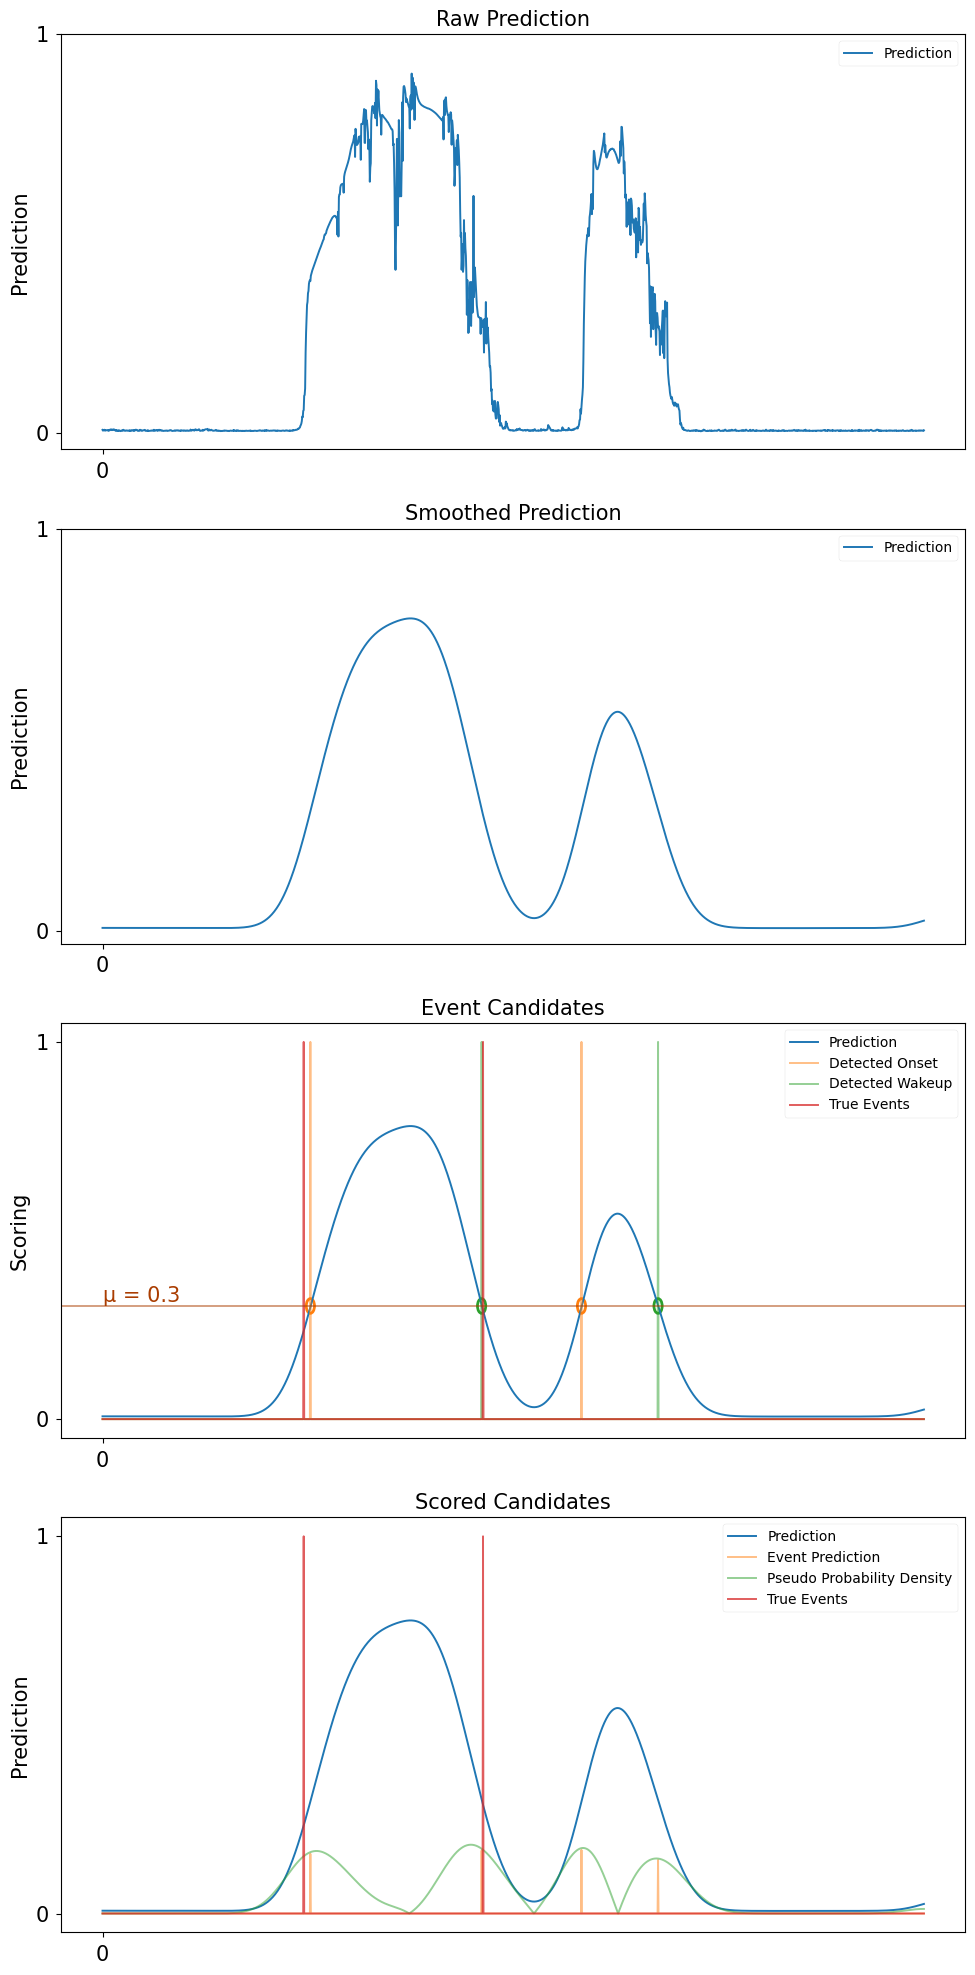

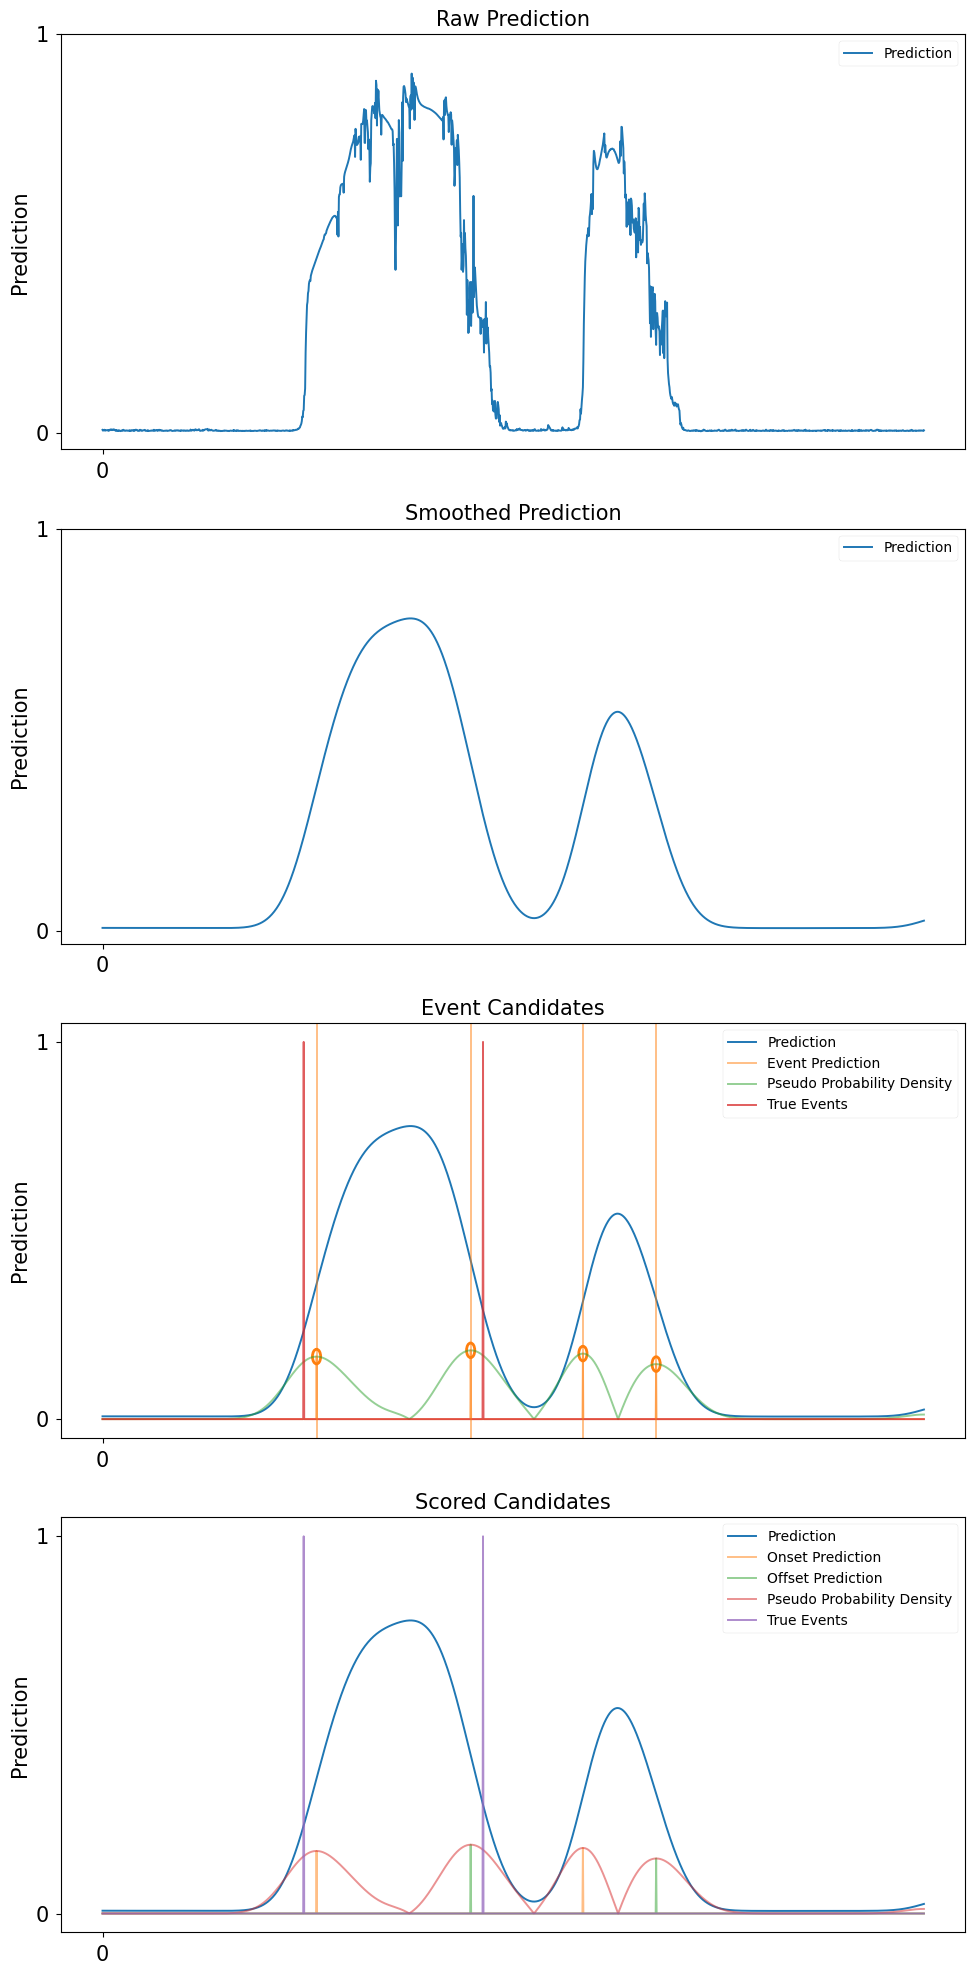

In [14]:
day_length = 24*60*12 // 10 
offset = day_length*10

x = np.load('/kaggle/input/sleep-cleaned-data/results_all/results_all/experiments/rnn/seg/predictions/038441c925bb.npy')[:,0]
x_filtered = gaussian_filter1d(x, sigma = 50)

true = pd.read_csv('/kaggle/input/child-mind-institute-detect-sleep-states/train_events.csv')
true = true.loc[true.series_id == '038441c925bb'].step.dropna().values.astype(int) // 10
gt = np.zeros(len(x))
gt[true] = 1

plt.figure(figsize=(20,4))
plt.plot(x[offset:offset+day_length], )

(cand1, cand2), (score1, score2), predictions = get_candidates(x, 'seg', max_distance = (12*3), day_length = day_length, threshold = 0.3)
scores = np.zeros((len(x),2))
scores[cand1,0] = 1#score1
scores[cand2,1] = 1#score2
# plt.plot(scores[offset:offset+day_length], alpha = 0.5)
# plt.plot(gt[offset:offset+day_length], alpha = 0.75)

plt.legend(['Prediction', 'Detected Onset', 'Detected Wakeup', 'True Events'],prop={'size': 15})
plt.ylabel('Prediction')
plt.yticks([0,1])
plt.xlabel('Time Axis')
plt.xticks([0])
plt.title('Raw Prediction')
plt.tight_layout()
plt.savefig('raw_segmentation_prediction_example')#bbox_inches='tight')
plt.show()


plt.figure(figsize=(20,4))
plt.plot(x_filtered[offset:offset+day_length], )

(cand1, cand2), (score1, score2), predictions= get_candidates(x_filtered, 'seg', max_distance = (12*3), day_length = day_length, threshold = 0.3)
scores = np.zeros((len(x),2))
scores[cand1,0] = 1#score1
scores[cand2,1] = 1#score2
# plt.plot(scores[offset:offset+day_length], alpha = 0.5)
# plt.plot(gt[offset:offset+day_length], alpha = 0.75)

plt.legend(['Prediction', 'Detected Onset', 'Detected Wakeup', 'True Events'],prop={'size': 15})
plt.ylabel('Prediction')
plt.yticks([0,1])
plt.xlabel('Time Axis')
plt.xticks([0])
plt.title('Smoothed Prediction')
plt.tight_layout()
plt.savefig('smooth_segmentation_prediction_example')#bbox_inches='tight')
plt.show()


plt.figure(figsize=(20,4))
ax = plt.gca()
plt.plot(x_filtered[offset:offset+day_length], )

lines = plt.plot(scores[offset:offset+day_length], alpha = 0.5)
plt.plot(gt[offset:offset+day_length], alpha = 0.75)
plt.axhline(0.3, color = orange_black[3], alpha = 0.5)
plt.text(0.1, 0.31, f'µ = 0.3', color = orange_black[3])

import matplotlib.patches
for cand in cand1:
    if cand > offset and cand < offset+day_length:
        circle1 = matplotlib.patches.Ellipse((cand-offset, 0.3), 0.01*day_length, 0.05*np.max(x_filtered[offset:offset+day_length]), color=lines[0].get_color(), lw=2, fill=False)
        ax.add_patch(circle1)
for cand in cand2:
    if cand > offset and cand < offset+day_length:
        circle2 = matplotlib.patches.Ellipse((cand-offset, 0.3), 0.01*day_length, 0.05*np.max(x_filtered[offset:offset+day_length]), color=lines[1].get_color(), lw=2, fill=False)
        ax.add_patch(circle2)
        

plt.legend(['Prediction', 'Detected Onset', 'Detected Wakeup', 'True Events'],prop={'size': 15})
plt.ylabel('Scoring')
plt.yticks([0,1])
plt.xlabel('Time Axis')
plt.xticks([0])
plt.title('Event Candidates')
plt.tight_layout()
plt.savefig('candidate_segmentation_prediction_example')#bbox_inches='tight')
plt.show()

plt.figure(figsize=(20,4))
plt.plot(x_filtered[offset:offset+day_length], )

scores = np.zeros((len(x),1))
scores[cand1,0] = score1
scores[cand2,0] = score2
predictions = np.abs(predictions)

plt.plot(scores[offset:offset+day_length], alpha = 0.5)
plt.plot(predictions[offset:offset+day_length], alpha = 0.5)
plt.plot(gt[offset:offset+day_length], alpha = 0.75)

plt.legend(['Prediction', 'Event Prediction', 'Pseudo Probability Density', 'True Events'],prop={'size': 15})
plt.ylabel('Prediction')
plt.yticks([0,1])
plt.xlabel('Time Axis')
plt.xticks([0])
plt.title('Scored Candidates')
plt.tight_layout()
plt.savefig('score1_segmentation_prediction_example')
plt.show()



plt.figure(figsize=(20,4))
plt.plot(x_filtered[offset:offset+day_length], )

(cand1, cand2), (score1, score2), predictions = get_candidates(x_filtered, 'seg2', max_distance = (12*3), day_length = day_length, threshold = 0.1)
scores = np.zeros((len(x),2))
scores[cand1,0] = score1
scores[cand2,1] = score2
predictions = np.abs(predictions)

plt.plot(scores[offset:offset+day_length], alpha = 0.5)
plt.plot(predictions[offset:offset+day_length], alpha = 0.5)
plt.plot(gt[offset:offset+day_length], alpha = 0.75)

plt.legend(['Prediction', 'Onset Prediction','Offset Prediction', 'Pseudo Probability Density',  'True Events'],prop={'size': 15})
plt.ylabel('Prediction')
plt.yticks([0,1])
plt.xlabel('Time Axis')
plt.xticks([0])
plt.title('Another Method')
plt.tight_layout()
plt.savefig('score2_segmentation_prediction_example')#bbox_inches='tight')
plt.show()

####
# combine all
####
fig, ax = plt.subplots(4, figsize=(10, 20))

x = np.load('/kaggle/input/sleep-cleaned-data/results_all/results_all/experiments/rnn/seg/predictions/038441c925bb.npy')[:,0]
x_filtered = gaussian_filter1d(x, sigma = 50)

true = pd.read_csv('/kaggle/input/child-mind-institute-detect-sleep-states/train_events.csv')
true = true.loc[true.series_id == '038441c925bb'].step.dropna().values.astype(int) // 10
gt = np.zeros(len(x))
gt[true] = 1

ax[0].plot(x[offset:offset+day_length], )
ax[0].legend(['Prediction', 'Detected Onset', 'Detected Wakeup', 'True Events'],prop={'size': 10},loc='upper right')
ax[0].set_title('Raw Prediction')
# ax[0].set_xlabel('Time Axis')
ax[0].set_xticks([0])
ax[0].set_ylabel('Prediction')
ax[0].set_yticks([0,1])

(cand1, cand2), (score1, score2), predictions = get_candidates(x, 'seg', max_distance = (12*3), day_length = day_length, threshold = 0.3)
scores = np.zeros((len(x),2))
scores[cand1,0] = 1#score1
scores[cand2,1] = 1#score2
# plt.plot(scores[offset:offset+day_length], alpha = 0.5)
# plt.plot(gt[offset:offset+day_length], alpha = 0.75)

ax[1].plot(x_filtered[offset:offset+day_length], )
ax[1].legend(['Prediction', 'Detected Onset', 'Detected Wakeup', 'True Events'],prop={'size': 10},loc='upper right')
ax[1].set_title('Smoothed Prediction')
# ax[1].set_xlabel('Time Axis')
ax[1].set_xticks([0])
ax[1].set_ylabel('Prediction')
ax[1].set_yticks([0,1])

(cand1, cand2), (score1, score2), predictions= get_candidates(x_filtered, 'seg', max_distance = (12*3), day_length = day_length, threshold = 0.3)
scores = np.zeros((len(x),2))
scores[cand1,0] = 1#score1
scores[cand2,1] = 1#score2

ax[2].plot(x_filtered[offset:offset+day_length], )
ax[2].plot(scores[offset:offset+day_length], alpha = 0.5)
ax[2].plot(gt[offset:offset+day_length], alpha = 0.75)
ax[2].axhline(0.3, color = orange_black[3], alpha = 0.5)
ax[2].text(0.1, 0.31, f'µ = 0.3', color = orange_black[3])

import matplotlib.patches
for cand in cand1:
    if cand > offset and cand < offset+day_length:
        circle1 = matplotlib.patches.Ellipse((cand-offset, 0.3), 0.01*day_length, 0.05*np.max(x_filtered[offset:offset+day_length]), color=lines[0].get_color(), lw=2, fill=False)
        ax[2].add_patch(circle1)
for cand in cand2:
    if cand > offset and cand < offset+day_length:
        circle2 = matplotlib.patches.Ellipse((cand-offset, 0.3), 0.01*day_length, 0.05*np.max(x_filtered[offset:offset+day_length]), color=lines[1].get_color(), lw=2, fill=False)
        ax[2].add_patch(circle2)

ax[2].legend(['Prediction', 'Detected Onset', 'Detected Wakeup', 'True Events'],prop={'size': 10},loc='upper right')
ax[2].set_title('Event Candidates')
# ax[2].set_xlabel('Time Axis')
ax[2].set_xticks([0])
ax[2].set_ylabel('Scoring')
ax[2].set_yticks([0,1])


ax[3].plot(x_filtered[offset:offset+day_length], )

scores = np.zeros((len(x),1))
scores[cand1,0] = score1
scores[cand2,0] = score2
predictions = np.abs(predictions)

ax[3].plot(scores[offset:offset+day_length], alpha = 0.5)
ax[3].plot(predictions[offset:offset+day_length], alpha = 0.5)
ax[3].plot(gt[offset:offset+day_length], alpha = 0.75)

ax[3].legend(['Prediction', 'Event Prediction', 'Pseudo Probability Density', 'True Events'],prop={'size': 10},loc='upper right')
ax[3].set_title('Scored Candidates')
# ax[3].set_xlabel('Time Axis')
ax[3].set_xticks([0])
ax[3].set_ylabel('Prediction')
ax[3].set_yticks([0,1])

plt.tight_layout()
plt.savefig('all_segmentation_m1_prediction_example', bbox_inches = 'tight',pad_inches = 0)
plt.show()

fig, ax = plt.subplots(4, figsize=(10, 20))

ax[0].plot(x[offset:offset+day_length], )
ax[0].legend(['Prediction', 'Detected Onset', 'Detected Wakeup', 'True Events'],prop={'size': 10},loc='upper right')
ax[0].set_title('Raw Prediction')
# ax[0].set_xlabel('Time Axis')
ax[0].set_xticks([0])
ax[0].set_ylabel('Prediction')
ax[0].set_yticks([0,1])

(cand1, cand2), (score1, score2), predictions = get_candidates(x, 'seg', max_distance = (12*3), day_length = day_length, threshold = 0.3)
scores = np.zeros((len(x),2))
scores[cand1,0] = 1#score1
scores[cand2,1] = 1#score2
# plt.plot(scores[offset:offset+day_length], alpha = 0.5)
# plt.plot(gt[offset:offset+day_length], alpha = 0.75)

ax[1].plot(x_filtered[offset:offset+day_length], )
ax[1].legend(['Prediction', 'Detected Onset', 'Detected Wakeup', 'True Events'],prop={'size': 10},loc='upper right')
ax[1].set_title('Smoothed Prediction')
# ax[1].set_xlabel('Time Axis')
ax[1].set_xticks([0])
ax[1].set_ylabel('Prediction')
ax[1].set_yticks([0,1])

(cand1, cand2), (score1, score2), predictions = get_candidates(x_filtered, 'seg2', max_distance = (12*3), day_length = day_length, threshold = 0.1)

ax[2].plot(x_filtered[offset:offset+day_length], )

scores = np.zeros((len(x),1))
scores[cand1,0] = score1
scores[cand2,0] = score2
predictions = np.abs(predictions)

lines = ax[2].plot(scores[offset:offset+day_length], alpha = 0.5)
ax[2].plot(predictions[offset:offset+day_length], alpha = 0.5)
ax[2].plot(gt[offset:offset+day_length], alpha = 0.75)

import matplotlib.patches
for cand in cand1:
    if cand > offset and cand < offset+day_length:
        ax[2].axvline(cand-offset, color=lines[0].get_color(), alpha = 0.5)
        circle1 = matplotlib.patches.Ellipse((cand-offset, predictions[cand]), 0.01*day_length, 0.05*np.max(x_filtered[offset:offset+day_length]), color=lines[0].get_color(), lw=2, fill=False)
        ax[2].add_patch(circle1)
for cand in cand2:
    if cand > offset and cand < offset+day_length:
        ax[2].axvline(cand-offset, color=lines[0].get_color(), alpha = 0.5)
        circle2 = matplotlib.patches.Ellipse((cand-offset, predictions[cand]), 0.01*day_length, 0.05*np.max(x_filtered[offset:offset+day_length]), color=lines[0].get_color(), lw=2, fill=False)
        ax[2].add_patch(circle2)

ax[2].legend(['Prediction', 'Event Prediction', 'Pseudo Probability Density', 'True Events'],prop={'size': 10},loc='upper right')
ax[2].set_title('Event Candidates')
# ax[3].set_xlabel('Time Axis')
ax[2].set_xticks([0])
ax[2].set_ylabel('Prediction')
ax[2].set_yticks([0,1])

ax[3].plot(x_filtered[offset:offset+day_length], )

scores = np.zeros((len(x),2))
scores[cand1,0] = score1
scores[cand2,1] = score2
predictions = np.abs(predictions)
ax[3].plot(scores[offset:offset+day_length], alpha = 0.5)
ax[3].plot(predictions[offset:offset+day_length], alpha = 0.5)
ax[3].plot(gt[offset:offset+day_length], alpha = 0.75)

ax[3].legend(['Prediction', 'Onset Prediction', 'Offset Prediction', 'Pseudo Probability Density',  'True Events'],prop={'size': 10},loc='upper right')
ax[3].set_title('Scored Candidates')
# ax[4].set_xlabel('Time Axis')
ax[3].set_xticks([0])
ax[3].set_ylabel('Prediction')
ax[3].set_yticks([0,1])

plt.tight_layout()
plt.savefig('all_segmentation_m2_prediction_example', bbox_inches = 'tight',pad_inches = 0)

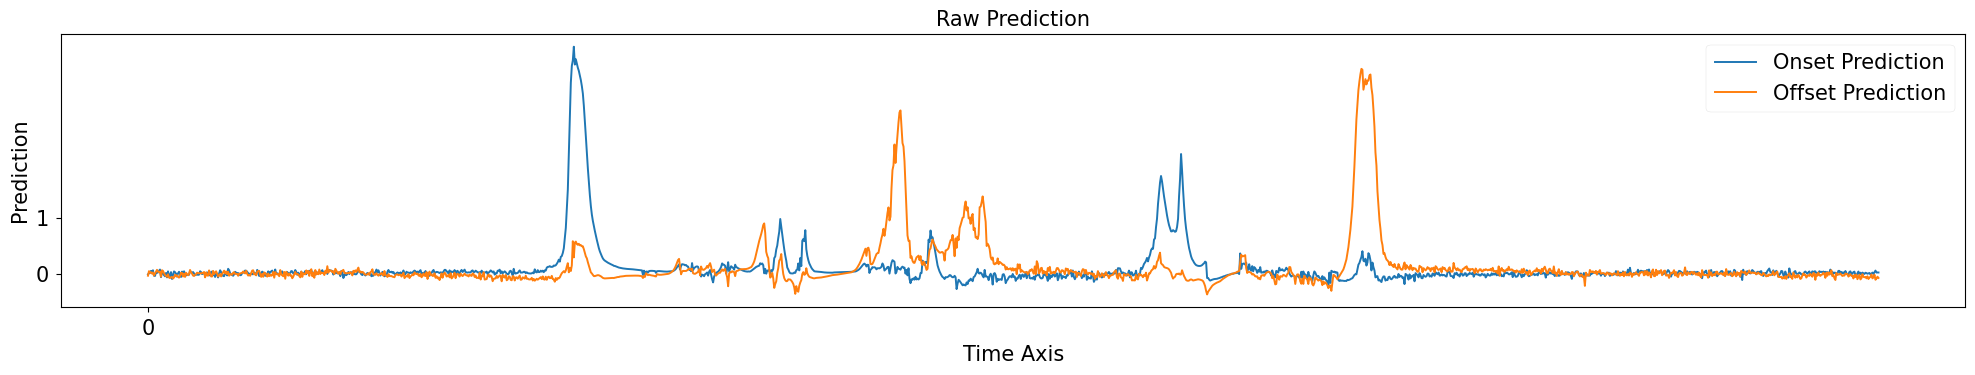

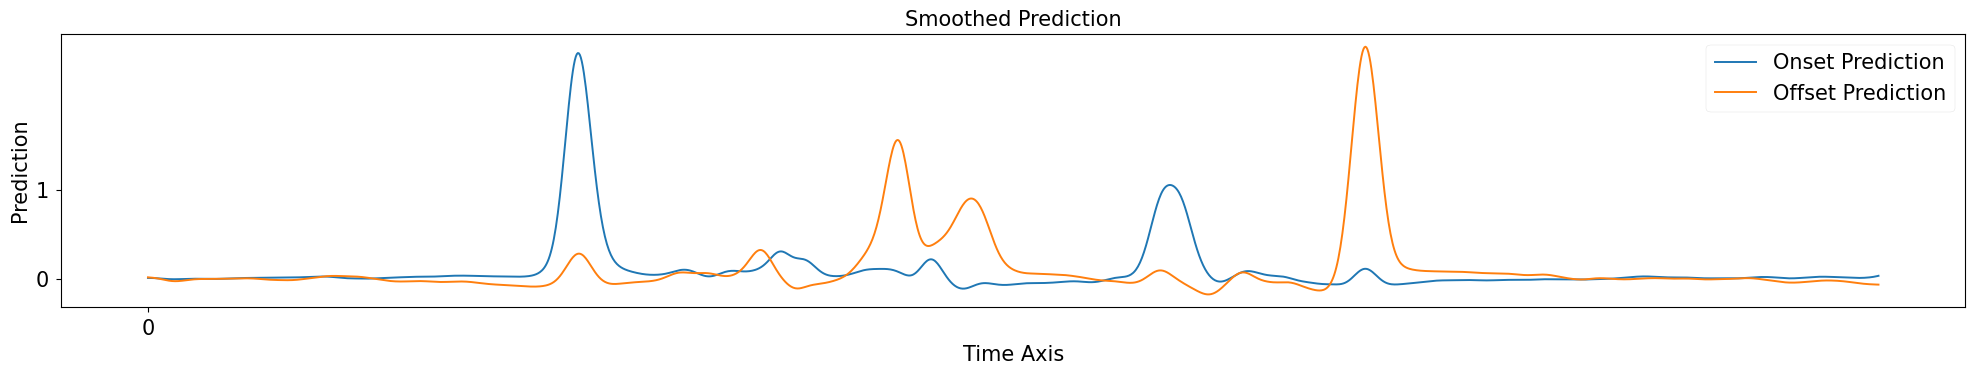

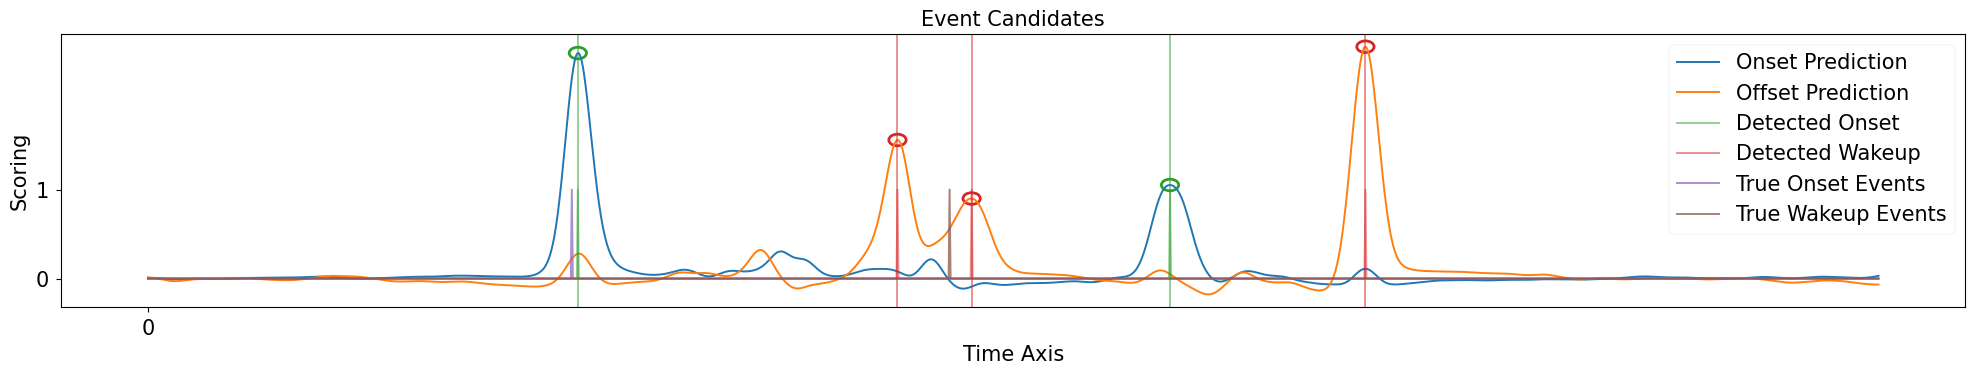

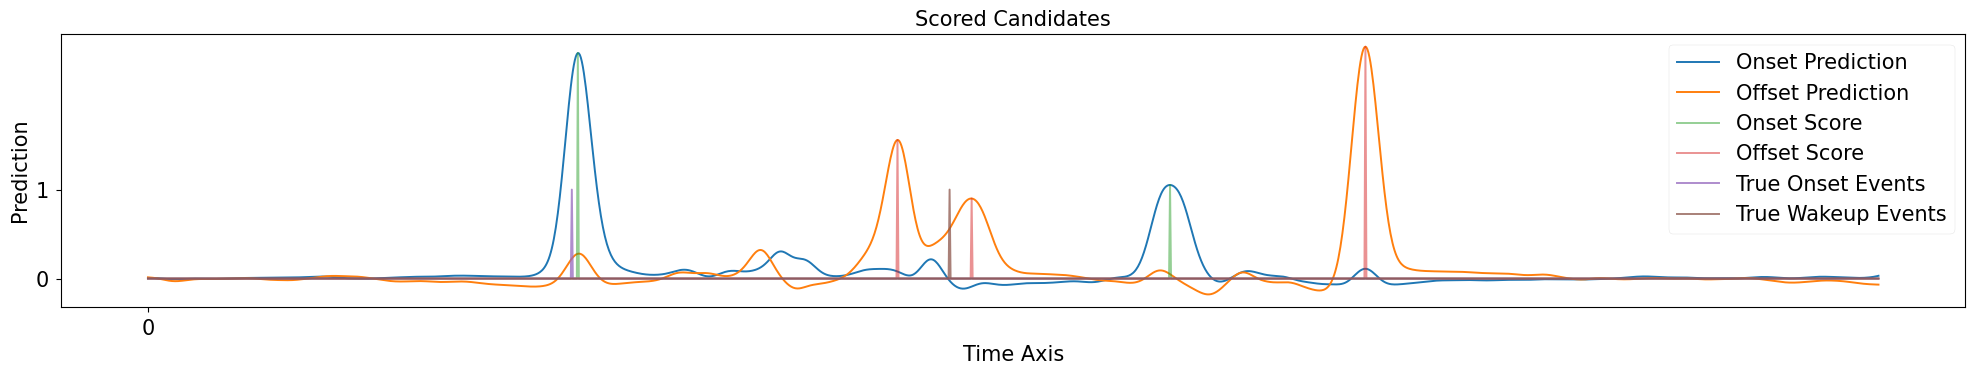

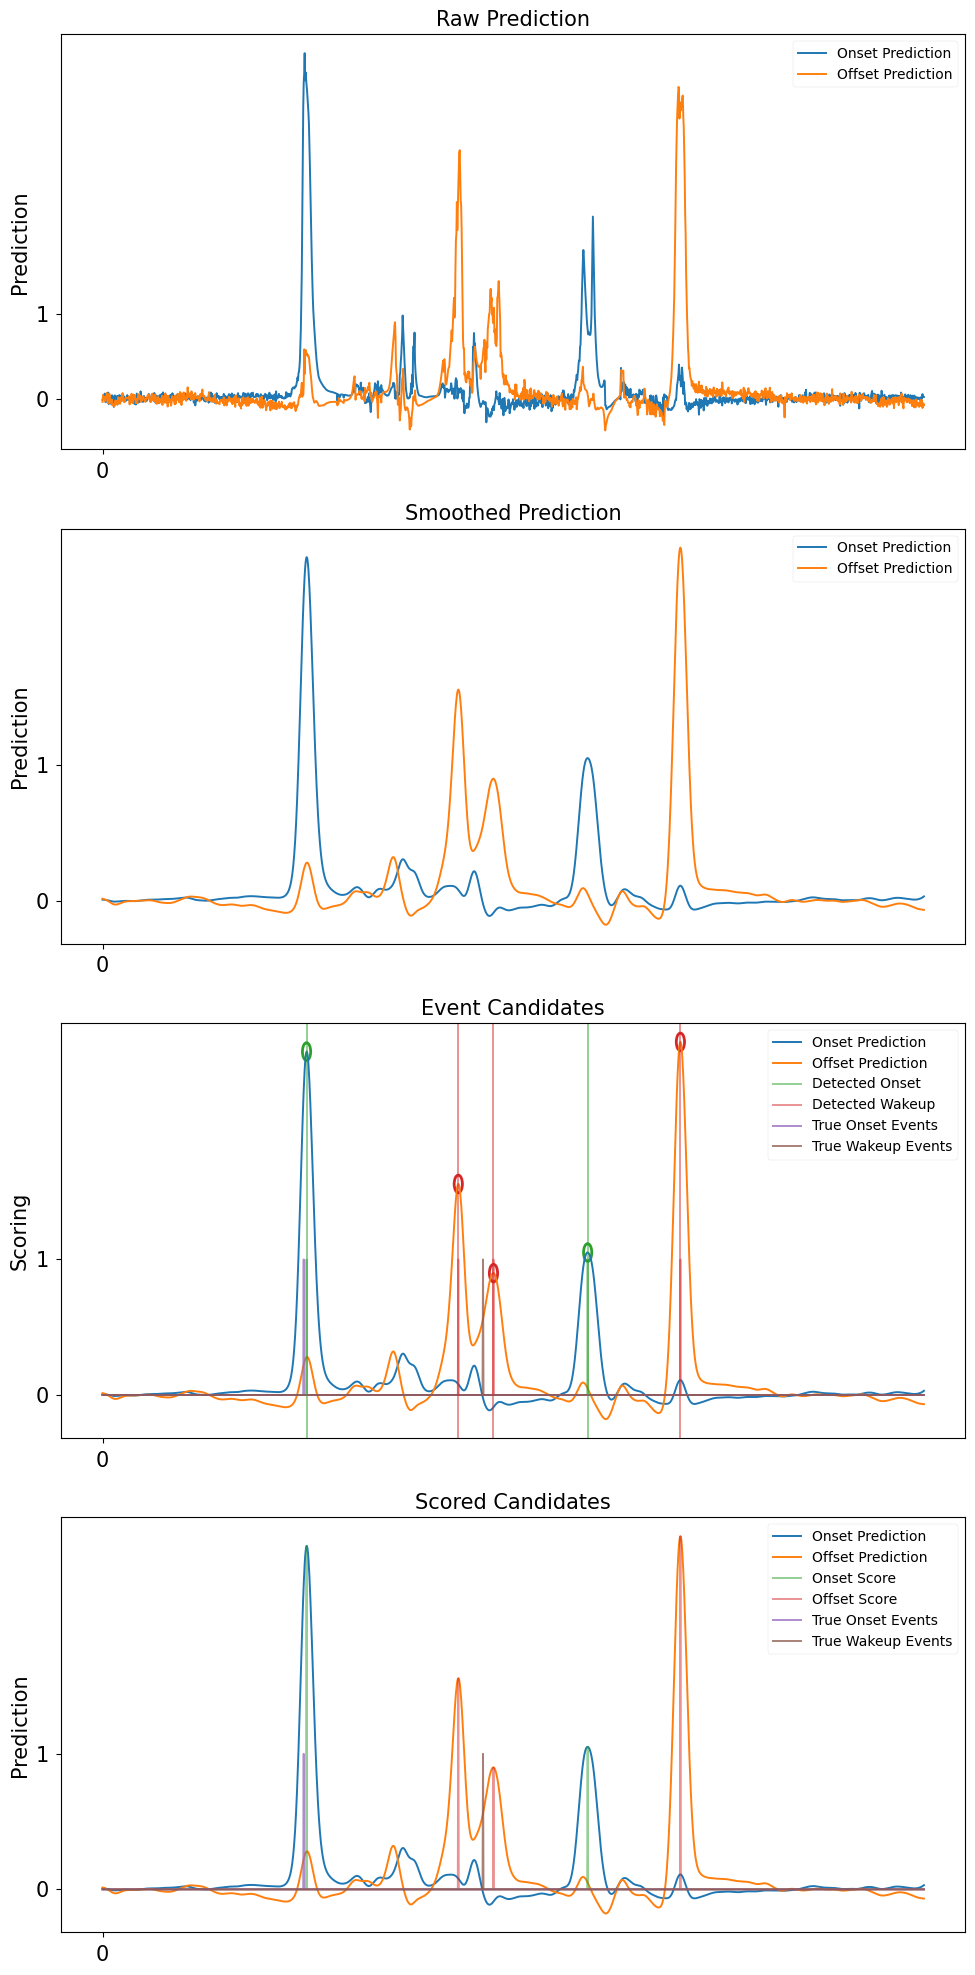

In [15]:
day_length = 24*60*12 // 10 
offset = day_length*10
threshold = 0.5

x = np.load('/kaggle/input/sleep-cleaned-data/results_all/results_all/experiments/rnn/gau/predictions/038441c925bb.npy')
x_filtered = x.copy()
x_filtered[:,0] = gaussian_filter1d(x[:,0], sigma = 10)
x_filtered[:,1] = gaussian_filter1d(x[:,1], sigma = 10)

gt = np.zeros((len(x),2))
true = pd.read_csv('/kaggle/input/child-mind-institute-detect-sleep-states/train_events.csv')
true_ = true.loc[(true.series_id == '038441c925bb') & (true.event == 'onset')].step.dropna().values.astype(int) // 10
gt[true_,0] = 1
true_ = true.loc[(true.series_id == '038441c925bb') & (true.event == 'wakeup')].step.dropna().values.astype(int) // 10
gt[true_,1] = 1

plt.figure(figsize=(20,4))
plt.plot(x[offset:offset+day_length], )

(cand1, cand2), (score1, score2), predictions = get_candidates(x, 'gau', max_distance = (12*3), day_length = day_length, threshold = threshold)
scores = np.zeros((len(x),2))
scores[cand1,0] = 1#score1
scores[cand2,1] = 1#score2

plt.legend(['Onset Prediction', 
            'Offset Prediction', ],prop={'size': 15})
plt.ylabel('Prediction')
plt.yticks([0,1])
plt.xlabel('Time Axis')
plt.xticks([0])
plt.title('Raw Prediction')
plt.tight_layout()
plt.savefig('raw_regression_prediction_example')#bbox_inches='tight')
plt.show()


plt.figure(figsize=(20,4))
plt.plot(x_filtered[offset:offset+day_length], )

plt.legend(['Onset Prediction', 
            'Offset Prediction', ],prop={'size': 15})
plt.ylabel('Prediction')
plt.yticks([0,1])
plt.xlabel('Time Axis')
plt.xticks([0])
plt.title('Smoothed Prediction')
plt.tight_layout()
plt.savefig('smooth_regression_prediction_example')#bbox_inches='tight')
plt.show()

(cand1, cand2), (score1, score2), predictions= get_candidates(x_filtered, 'gau', max_distance = (12*3), day_length = day_length, threshold = threshold)
scores = np.zeros((len(x),2))
scores[cand1,0] = 1#score1
scores[cand2,1] = 1#score2

plt.figure(figsize=(20,4))
ax = plt.gca()
plt.plot(x_filtered[offset:offset+day_length], )

lines = plt.plot(scores[offset:offset+day_length], alpha = 0.5)
plt.plot(gt[offset:offset+day_length], alpha = 0.75)

import matplotlib.patches
for cand in cand1:
    if cand > offset and cand < offset+day_length:
        plt.axvline(cand-offset, color=lines[0].get_color(), alpha = 0.5)
        circle1 = matplotlib.patches.Ellipse((cand-offset, x_filtered[cand,0]), 0.01*day_length, 0.05*np.max(x_filtered[offset:offset+day_length]), color=lines[0].get_color(), lw=2, fill=False)
        ax.add_patch(circle1)
for cand in cand2:
    if cand > offset and cand < offset+day_length:
        plt.axvline(cand-offset, color=lines[1].get_color(), alpha = 0.5)
        circle2 = matplotlib.patches.Ellipse((cand-offset, x_filtered[cand,1]), 0.01*day_length, 0.05*np.max(x_filtered[offset:offset+day_length]), color=lines[1].get_color(), lw=2, fill=False)
        ax.add_patch(circle2)

# plt.axhspan(threshold, np.max(x), color=orange_black[3], alpha=0.1)
# plt.axhline(threshold, color = orange_black[3], alpha = 0.5)
# plt.text(0.1, threshold+0.01, f'µ = {threshold}', color = orange_black[3])

plt.legend(['Onset Prediction', 
            'Offset Prediction', 
            'Detected Onset', 
            'Detected Wakeup',
            'True Onset Events', 
            'True Wakeup Events',],prop={'size': 15})
plt.ylabel('Scoring')
plt.yticks([0,1])
plt.xlabel('Time Axis')
plt.xticks([0])
plt.title('Event Candidates')
plt.tight_layout()
plt.savefig('candidate_regression_prediction_example')#bbox_inches='tight')
plt.show()

plt.figure(figsize=(20,4))
plt.plot(x_filtered[offset:offset+day_length], )

scores = np.zeros((len(x),2))
scores[cand1,0] = score1
scores[cand2,1] = score2

plt.plot(scores[offset:offset+day_length], alpha = 0.5)
plt.plot(gt[offset:offset+day_length], alpha = 0.75)

plt.legend(['Onset Prediction', 
            'Offset Prediction', 
            'Onset Score', 
            'Offset Score', 
            'True Onset Events', 
            'True Wakeup Events',],prop={'size': 15})
plt.ylabel('Prediction')
plt.yticks([0,1])
plt.xlabel('Time Axis')
plt.xticks([0])
plt.title('Scored Candidates')
plt.tight_layout()
plt.savefig('score_regression_prediction_example')
plt.tight_layout()
plt.show()

day_length = 24*60*12 // 10 
offset = day_length*10
threshold = 0.5

# fig, ax = plt.subplots(4, figsize=(20, 4*12/5))
fig, ax = plt.subplots(4, figsize=(10, 20))

x = np.load('/kaggle/input/sleep-cleaned-data/results_all/results_all/experiments/rnn/gau/predictions/038441c925bb.npy')
x_filtered = x.copy()
x_filtered[:,0] = gaussian_filter1d(x[:,0], sigma = 10)
x_filtered[:,1] = gaussian_filter1d(x[:,1], sigma = 10)

gt = np.zeros((len(x),2))
true = pd.read_csv('/kaggle/input/child-mind-institute-detect-sleep-states/train_events.csv')
true_ = true.loc[(true.series_id == '038441c925bb') & (true.event == 'onset')].step.dropna().values.astype(int) // 10
gt[true_,0] = 1
true_ = true.loc[(true.series_id == '038441c925bb') & (true.event == 'wakeup')].step.dropna().values.astype(int) // 10
gt[true_,1] = 1

ax[0].plot(x[offset:offset+day_length], )

(cand1, cand2), (score1, score2), predictions = get_candidates(x, 'gau', max_distance = (12*3), day_length = day_length, threshold = threshold)
scores = np.zeros((len(x),2))
scores[cand1,0] = 1#score1
scores[cand2,1] = 1#score2

ax[0].legend(['Onset Prediction', 
            'Offset Prediction', ],prop={'size': 10},loc='upper right')
ax[0].set_ylabel('Prediction')
ax[0].set_yticks([0,1])
# ax[0].set_xlabel('Time Axis')
ax[0].set_xticks([0])
ax[0].set_title('Raw Prediction')

ax[1].plot(x_filtered[offset:offset+day_length], )
ax[1].legend(['Onset Prediction', 
            'Offset Prediction', ],prop={'size': 10},loc='upper right')
ax[1].set_ylabel('Prediction')
ax[1].set_yticks([0,1])
# ax[1].set_xlabel('Time Axis')
ax[1].set_xticks([0])
ax[1].set_title('Smoothed Prediction')

(cand1, cand2), (score1, score2), predictions= get_candidates(x_filtered, 'gau', max_distance = (12*3), day_length = day_length, threshold = threshold)
scores = np.zeros((len(x),2))
scores[cand1,0] = 1#score1
scores[cand2,1] = 1#score2

ax[2].plot(x_filtered[offset:offset+day_length], )
lines = ax[2].plot(scores[offset:offset+day_length], alpha = 0.5)
ax[2].plot(gt[offset:offset+day_length], alpha = 0.75)

import matplotlib.patches
for cand in cand1:
    if cand > offset and cand < offset+day_length:
        ax[2].axvline(cand-offset, color=lines[0].get_color(), alpha = 0.5)
        circle1 = matplotlib.patches.Ellipse((cand-offset, x_filtered[cand,0]), 0.01*day_length, 0.05*np.max(x_filtered[offset:offset+day_length]), color=lines[0].get_color(), lw=2, fill=False)
        ax[2].add_patch(circle1)
for cand in cand2:
    if cand > offset and cand < offset+day_length:
        ax[2].axvline(cand-offset, color=lines[1].get_color(), alpha = 0.5)
        circle2 = matplotlib.patches.Ellipse((cand-offset, x_filtered[cand,1]), 0.01*day_length, 0.05*np.max(x_filtered[offset:offset+day_length]), color=lines[1].get_color(), lw=2, fill=False)
        ax[2].add_patch(circle2)

# ax[2].axhspan(threshold, np.max(x), color=orange_black[3], alpha=0.1)
# ax[2].axhline(threshold, color = orange_black[3], alpha = 0.5)
# ax[2].text(0.1, threshold+0.01, f'µ = {threshold}', color = orange_black[3])

ax[2].legend(['Onset Prediction', 
            'Offset Prediction', 
            'Detected Onset', 
            'Detected Wakeup',
            'True Onset Events', 
            'True Wakeup Events',],prop={'size': 10},loc='upper right')
ax[2].set_ylabel('Scoring')
ax[2].set_yticks([0,1])
# ax[2].set_xlabel('Time Axis')
ax[2].set_xticks([0])
ax[2].set_title('Event Candidates')

ax[3].plot(x_filtered[offset:offset+day_length], )

scores = np.zeros((len(x),2))
scores[cand1,0] = score1
scores[cand2,1] = score2

ax[3].plot(scores[offset:offset+day_length], alpha = 0.5)
ax[3].plot(gt[offset:offset+day_length], alpha = 0.75)
ax[3].legend(['Onset Prediction', 
            'Offset Prediction', 
            'Onset Score', 
            'Offset Score', 
            'True Onset Events', 
            'True Wakeup Events',],prop={'size': 10},loc='upper right')
ax[3].set_ylabel('Prediction')
ax[3].set_yticks([0,1])
# ax[3].set_xlabel('Time Axis')
ax[3].set_xticks([0])
ax[3].set_title('Scored Candidates')
plt.tight_layout()
plt.savefig('all_regression_prediction_example', bbox_inches = 'tight',pad_inches = 0)
plt.show()

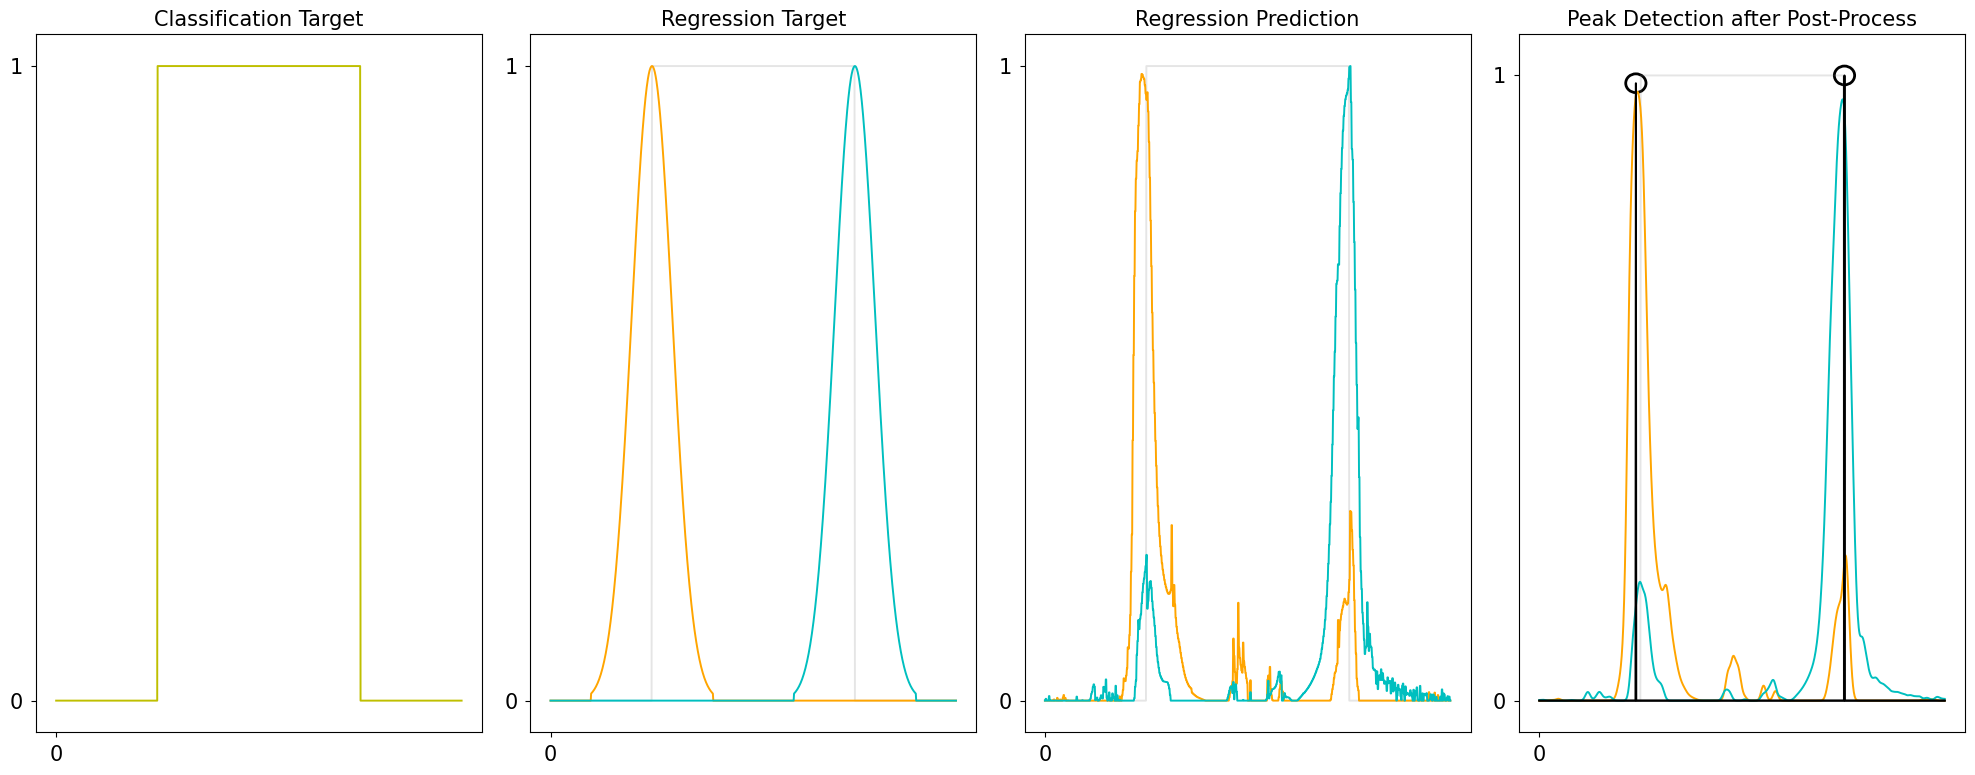

In [16]:
fig, ax = plt.subplots(1,4, figsize=(20, 8))

state_orig = np.array([0]* 250 + [1]*500 + [0]*250)
y = [[250, 750]]
xs = np.arange(len(state_orig))
out = get_targets(state_orig, y, 'gau',50)
target0,target1 = out[:,0], out[:,1]

ax[0].plot(xs, state_orig, c = colors[3])
ax[0].set_title('Classification Target')
# ax[0].set_xlabel('Time Axis')
ax[0].set_xticks([0])
# ax[2].set_ylabel('Target')
ax[0].set_yticks([0,1])

ax[1].plot(xs, state_orig, c = 'gray',alpha=0.2)


ax[1].plot(xs, out[:,0], c = colors[1])
ax[1].plot(xs, out[:,1], c = colors[2])
ax[1].set_title('Regression Target')
# ax[1].set_xlabel('Time Axis')
ax[1].set_xticks([0])
# ax[1].set_ylabel('Target')
ax[1].set_yticks([0,1])


pred = np.zeros((len(state_orig),2))
x = np.load('/kaggle/input/sleep-cleaned-data/results_all/results_all/experiments/rnn/gau/predictions/03d92c9f6f8a.npy')
true = pd.read_csv('/kaggle/input/child-mind-institute-detect-sleep-states/train_events.csv')
true_ = true.loc[(true.series_id == '03d92c9f6f8a') & (true.event == 'onset')].step.dropna().values.astype(int) // 10 *2
pred[0:500] = np.repeat(x, 2,0)[true_[0]-250:true_[0]+250]
true_ = true.loc[(true.series_id == '03d92c9f6f8a') & (true.event == 'wakeup')].step.dropna().values.astype(int) // 10 *2
pred[500:1000] = np.repeat(x, 2,0)[true_[0]-250:true_[0]+250]

pred = pred/np.max(pred)
pred[pred<0] = 0

ax[2].plot(xs, state_orig, c =  'gray', alpha=0.2)


ax[2].plot(xs, pred[:,0], c = colors[1])
ax[2].plot(xs, pred[:,1], c = colors[2])
ax[2].set_title('Regression Prediction')
# ax[2].set_xlabel('Time Axis')
ax[2].set_xticks([0])
# ax[2].set_ylabel('Target')
ax[2].set_yticks([0,1])

(cand1, cand2), (score1, score2), predictions= get_candidates(pred, 'gau', max_distance = (12*3), day_length = day_length, threshold = 0.5)
scores = np.zeros((len(pred),2))
scores[cand1,0] = score1
scores[cand2,1] = score2

ax[3].plot(xs, state_orig, c = 'gray',alpha=0.2)

# ax[3].plot(xs, pred[:,0], c =  'gray', alpha = 0.5)
# ax[3].plot(xs, pred[:,1], c =  'gray', alpha = 0.5)

ax[3].plot(xs, gaussian_filter1d(pred[:,0], sigma = 5), c = colors[1], alpha = 1)
ax[3].plot(xs, gaussian_filter1d(pred[:,1], sigma = 5), c = colors[2], alpha = 1)

ax[3].plot(xs, scores[:,0], c = 'black', alpha = 1)
ax[3].plot(xs, scores[:,1], c = 'black', alpha = 1)

# ax[3].axvline(cand1, color = colors[4], alpha = 0.5, lw=1)
# ax[3].axvline(cand2, color = colors[4], alpha = 0.5, lw=1)
import matplotlib.patches
circle1 = matplotlib.patches.Ellipse((cand1, score1), 0.05*len(pred), 0.03, color='black', lw=2, fill=False)
circle2 = matplotlib.patches.Ellipse((cand2, score2), 0.05*len(pred), 0.03, color='black', lw=2,fill=False)
ax[3].add_patch(circle1)
ax[3].add_patch(circle2)

ax[3].set_title('Peak Detection after Post-Process')
# ax[3].set_xlabel('Time Axis')
ax[3].set_xticks([0])
# ax[3].set_ylabel('Target')
ax[3].set_yticks([0,1])

plt.tight_layout()
plt.savefig('regression_prediction_sample1')
plt.show()

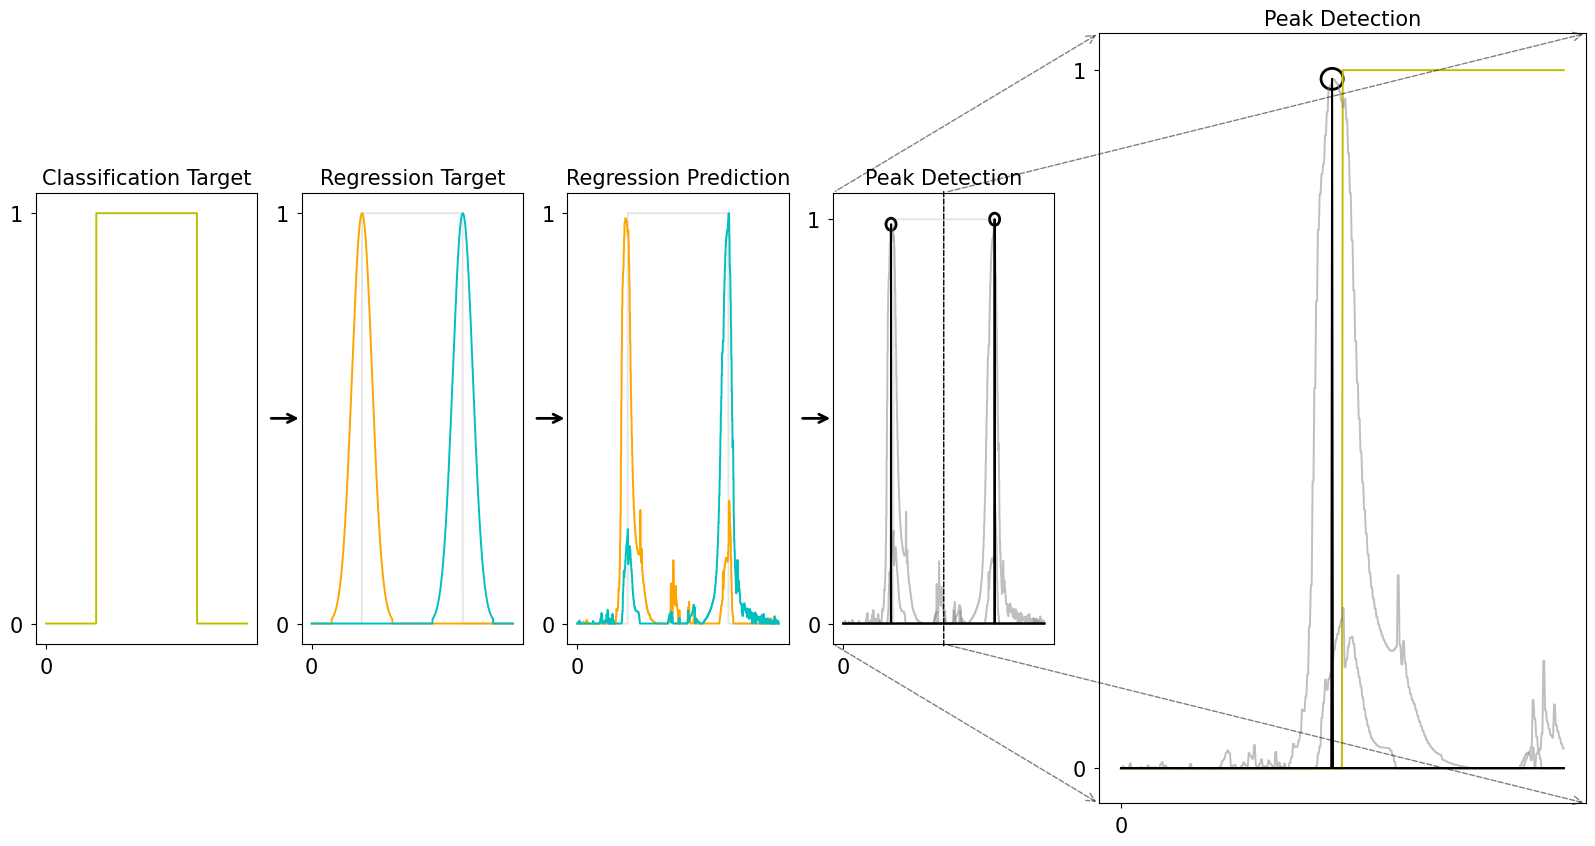

In [17]:
fig = plt.figure(figsize=(20, 10))
grid = plt.GridSpec(5, 6)
axes = []

import matplotlib.gridspec as gridspec
left_grid = gridspec.GridSpecFromSubplotSpec(1, 4, grid[1:4,0:4])
# right_grid = gridspec.GridSpecFromSubplotSpec(1, 4, grid[0:3,1])

state_orig = np.array([0]* 250 + [1]*500 + [0]*250)
y = [[250, 750]]
xs = np.arange(len(state_orig))
out = get_targets(state_orig, y, 'gau',50)
target0,target1 = out[:,0], out[:,1]

ax = plt.subplot(left_grid[0, 0])
ax.plot(xs, state_orig, c = colors[3])
ax.set_title('Classification Target')
ax.set_xticks([0])
ax.set_yticks([0,1])
axes.append(ax)

ax = plt.subplot(left_grid[0, 1])
ax.plot(xs, state_orig, c = 'gray',alpha=0.2)
ax.plot(xs, out[:,0], c = colors[1])
ax.plot(xs, out[:,1], c = colors[2])
ax.set_title('Regression Target')
ax.set_xticks([0])
ax.set_yticks([0,1])
axes.append(ax)


pred = np.zeros((len(state_orig),2))
x = np.load('/kaggle/input/sleep-cleaned-data/results_all/results_all/experiments/rnn/gau/predictions/03d92c9f6f8a.npy')
true = pd.read_csv('/kaggle/input/child-mind-institute-detect-sleep-states/train_events.csv')
true_ = true.loc[(true.series_id == '03d92c9f6f8a') & (true.event == 'onset')].step.dropna().values.astype(int) // 10 *2
pred[0:500] = np.repeat(x, 2,0)[true_[0]-250:true_[0]+250]
true_ = true.loc[(true.series_id == '03d92c9f6f8a') & (true.event == 'wakeup')].step.dropna().values.astype(int) // 10 *2
pred[500:1000] = np.repeat(x, 2,0)[true_[0]-250:true_[0]+250]

pred = pred/np.max(pred)
pred[pred<0] = 0

ax = plt.subplot(left_grid[0, 2])
ax.plot(xs, state_orig, c =  'gray', alpha=0.2)
ax.plot(xs, pred[:,0], c = colors[1])
ax.plot(xs, pred[:,1], c = colors[2])
ax.set_title('Regression Prediction')
ax.set_xticks([0])
ax.set_yticks([0,1])
axes.append(ax)

(cand1, cand2), (score1, score2), predictions= get_candidates(pred, 'gau', max_distance = (12*3), day_length = day_length, threshold = 0.5)
scores = np.zeros((len(pred),2))
scores[cand1,0] = score1
scores[cand2,1] = score2

ax = plt.subplot(left_grid[0, 3])
ax.plot(xs, state_orig, c = 'gray',alpha=0.2)

ax.plot(xs, pred[:,0], c =  'gray', alpha = 0.5)
ax.plot(xs, pred[:,1], c =  'gray', alpha = 0.5)

# ax.plot(xs, gaussian_filter1d(pred[:,0], sigma = 5), c = colors[1], alpha = 1)
# ax.plot(xs, gaussian_filter1d(pred[:,1], sigma = 5), c = colors[2], alpha = 1)

ax.plot(xs, scores[:,0], c = 'black', alpha = 1)
ax.plot(xs, scores[:,1], c = 'black', alpha = 1)

# ax[3].axvline(cand1, color = colors[4], alpha = 0.5, lw=1)
# ax[3].axvline(cand2, color = colors[4], alpha = 0.5, lw=1)
import matplotlib.patches
circle1 = matplotlib.patches.Ellipse((cand1, score1), 0.05*len(pred), 0.03, color='black', lw=2, fill=False)
circle2 = matplotlib.patches.Ellipse((cand2, score2), 0.05*len(pred), 0.03, color='black', lw=2,fill=False)
ax.add_patch(circle1)
ax.add_patch(circle2)

ax.set_title('Peak Detection')
# ax[3].set_xlabel('Time Axis')
ax.set_xticks([0])
# ax[3].set_ylabel('Target')
ax.set_yticks([0,1])
axes.append(ax)

ax = plt.subplot(grid[:, 4:])
ax.plot(xs[:500], state_orig[:500], c = colors[3],alpha=1.0)

ax.plot(xs[:500], pred[:500,0], c =  'gray', alpha = 0.5)
ax.plot(xs[:500], pred[:500,1], c =  'gray', alpha = 0.5)

# ax.plot(xs, gaussian_filter1d(pred[:,0], sigma = 5), c = colors[1], alpha = 1)
# ax.plot(xs, gaussian_filter1d(pred[:,1], sigma = 5), c = colors[2], alpha = 1)

ax.plot(xs[:500], scores[:500,0], c = 'black', alpha = 1)
ax.plot(xs[:500], scores[:500,1], c = 'black', alpha = 1)

# ax[3].axvline(cand1, color = colors[4], alpha = 0.5, lw=1)
# ax[3].axvline(cand2, color = colors[4], alpha = 0.5, lw=1)
import matplotlib.patches
circle1 = matplotlib.patches.Ellipse((cand1, score1), 0.05*500, 0.03, color='black', lw=2, fill=False)
# circle2 = matplotlib.patches.Ellipse((cand2, score2), 0.05*50, 0.03, color='black', lw=2,fill=False)
ax.add_patch(circle1)
# ax.add_patch(circle2)

ax.set_title('Peak Detection')
# ax[3].set_xlabel('Time Axis')
ax.set_xticks([0])
# ax[3].set_ylabel('Target')
ax.set_yticks([0,1])
axes.append(ax)


arrowprops = dict(arrowstyle="<-", linewidth=2, color='black')
arrow1_2 = plt.annotate('', xy=(1.05, 0.5), xycoords=axes[0].transAxes, xytext=(0, 0.5), textcoords=axes[1].transAxes, arrowprops=arrowprops)
# plt.text(0.43, 0.7, 'Annotation 1-2', transform=fig.transFigure, fontsize=12, color='red')
arrow2_3 = plt.annotate('', xy=(1.05, 0.5), xycoords=axes[1].transAxes, xytext=(0, 0.5), textcoords=axes[2].transAxes, arrowprops=arrowprops)
# plt.text(0.75, 0.5, 'Annotation 3-2', transform=fig.transFigure, fontsize=12, color='red')
arrow3_4 = plt.annotate('', xy=(1.05, 0.5), xycoords=axes[2].transAxes, xytext=(0, 0.5), textcoords=axes[3].transAxes, arrowprops=arrowprops)
# plt.text(0.43, 0.3, 'Annotation 1-3', transform=fig.transFigure, fontsize=12, color='red')
arrowprops = dict(arrowstyle="<-", linestyle="dashed", linewidth=1, color='black',alpha = 0.5)
arrow4_5_1 = plt.annotate('', xy=(0, 1), xycoords=axes[3].transAxes, xytext=(0, 1), textcoords=axes[4].transAxes, arrowprops=arrowprops)
arrow4_5_2 = plt.annotate('', xy=(0, 0), xycoords=axes[3].transAxes, xytext=(0, 0), textcoords=axes[4].transAxes, arrowprops=arrowprops)
arrow4_5_4 = plt.annotate('', xy=(0.5, 1), xycoords=axes[3].transAxes, xytext=(1, 1), textcoords=axes[4].transAxes, arrowprops=arrowprops)
arrow4_5_4 = plt.annotate('', xy=(0.5, 0), xycoords=axes[3].transAxes, xytext=(1, 0), textcoords=axes[4].transAxes, arrowprops=arrowprops)

arrowprops = dict(arrowstyle = '-', linestyle="dashed", linewidth=1, color='black',alpha = 1)
arrow4_5_3 = plt.annotate('', xy=(0.5, 1.01), xycoords=axes[3].transAxes, xytext=(0.5, -0.01), textcoords=axes[3].transAxes, arrowprops=arrowprops)

# plt.tight_layout()
plt.savefig('regression_prediction_sample2')
plt.show()

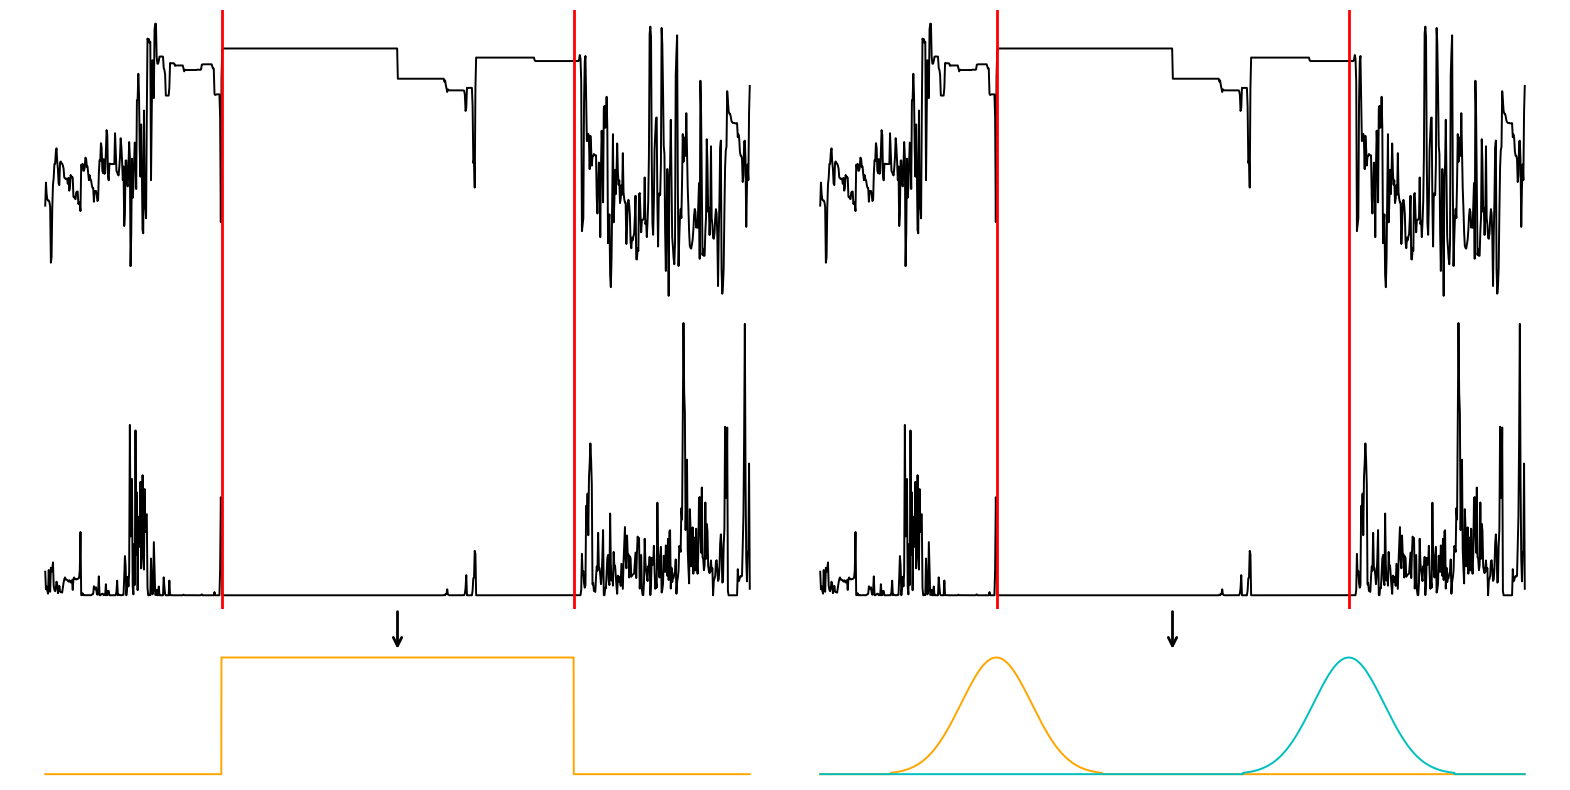

In [18]:
fig = plt.figure(figsize=(20, 10))
grid = plt.GridSpec(18, 2)
axes = []

import matplotlib.gridspec as gridspec

pred = np.zeros((1000,2))
x = np.load('/kaggle/input/sleep-cleaned-data/results_all/results_all/experiments/rnn/gau/predictions/03d92c9f6f8a.npy')
true = pd.read_csv('/kaggle/input/child-mind-institute-detect-sleep-states/train_events.csv')
onset_time = true.loc[(true.series_id == '03d92c9f6f8a') & (true.event == 'onset')].step.dropna().values.astype(int)[0]
true_ = onset_time // 10 *2
pred[0:500] = x[true_-250:true_+250]
offset_time = true.loc[(true.series_id == '03d92c9f6f8a') & (true.event == 'wakeup')].step.dropna().values.astype(int)[0]
true_ = offset_time // 10 *2
pred[500:1000] = x[true_-250:true_+250]


xs = np.arange(len(state_orig))
feats = pd.read_parquet('/kaggle/input/child-mind-institute-detect-sleep-states/train_series.parquet',filters=[('series_id', '=', '03d92c9f6f8a')])
# feats = feats[::10]
enmo = np.concatenate([feats['enmo'].values[onset_time-250:onset_time+250],
                       feats['enmo'].values[offset_time-250:offset_time+250]],axis=0)
anglez = np.concatenate([feats['anglez'].values[onset_time-250:onset_time+250],
                       feats['anglez'].values[offset_time-250:offset_time+250]],axis=0)

ax = plt.subplot(grid[0:7, 0:1])
ax.plot(anglez, c = 'black')
ax.axvline(250, color = 'red', alpha = 1, lw=2)
ax.axvline(750, color = 'red', alpha = 1, lw=2)
# ax.set_title('Classification Target')
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')
axes.append(ax)

ax = plt.subplot(grid[7:14, 0:1])
ax.plot(enmo, c = 'black')
ax.axvline(250, color = 'red', alpha = 1, lw=2)
ax.axvline(750, color = 'red', alpha = 1, lw=2)
# ax.set_title('Classification Target')
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')
axes.append(ax)

ax = plt.subplot(grid[0:7, 1:2])
ax.plot(anglez, c = 'black')
ax.axvline(250, color = 'red', alpha = 1, lw=2)
ax.axvline(750, color = 'red', alpha = 1, lw=2)
# ax.set_title('Classification Target')
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')
axes.append(ax)

ax = plt.subplot(grid[7:14, 1:2])
ax.plot(enmo, c = 'black')
ax.axvline(250, color = 'red', alpha = 1, lw=2)
ax.axvline(750, color = 'red', alpha = 1, lw=2)
# ax.set_title('Classification Target')
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')
axes.append(ax)


state_orig = np.array([0]* 2500 + [1]*5000 + [0]*2500)
xs = np.arange(10000)
y = [[2500, 7500]]
out = get_targets(state_orig, y, 'gau',500)
target0,target1 = out[:,0], out[:,1]

ax = plt.subplot(grid[15:18, 0])
ax.plot(xs, state_orig, c =  'orange', alpha=1)
# ax.plot(xs, pred[:,0], c = colors[1])
# ax.plot(xs, pred[:,1], c = colors[2])
# ax.set_title('Classification')
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')
axes.append(ax)

ax = plt.subplot(grid[15:18, 1])
# ax.plot(xs, state_orig, c =  'gray', alpha=0.2)
ax.plot(xs, target0, c = colors[1])
ax.plot(xs, target1, c = colors[2])
# ax.set_title('Regression')
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')
axes.append(ax)

grid.update(wspace=0, hspace=0)

arrowprops = dict(arrowstyle="<-", linewidth=2, color='black')
arrow1_2 = plt.annotate('', xy=(0.5, 0), xycoords=axes[1].transAxes, xytext=(0.5, 1), textcoords=axes[-2].transAxes, arrowprops=arrowprops)
# plt.text(0.43, 0.7, 'Annotation 1-2', transform=fig.transFigure, fontsize=12, color='red')
arrow2_3 = plt.annotate('', xy=(0.5, 0), xycoords=axes[3].transAxes, xytext=(0.5, 1), textcoords=axes[-1].transAxes, arrowprops=arrowprops)
# plt.text(0.75, 0.5, 'Annotation 3-2', transform=fig.transFigure, fontsize=12, color='red')
# arrow3_4 = plt.annotate('', xy=(1.05, 0.5), xycoords=axes[2].transAxes, xytext=(0, 0.5), textcoords=axes[3].transAxes, arrowprops=arrowprops)
# # plt.text(0.43, 0.3, 'Annotation 1-3', transform=fig.transFigure, fontsize=12, color='red')
# arrowprops = dict(arrowstyle="<-", linestyle="dashed", linewidth=1, color='black',alpha = 0.5)
# arrow4_5_1 = plt.annotate('', xy=(0, 0), xycoords=axes[1].transAxes, xytext=(0, 0), textcoords=axes[-2].transAxes, arrowprops=arrowprops)
# arrow4_5_2 = plt.annotate('', xy=(0, 0), xycoords=axes[3].transAxes, xytext=(0, 0), textcoords=axes[-1].transAxes, arrowprops=arrowprops)
# arrow4_5_4 = plt.annotate('', xy=(0.5, 1), xycoords=axes[3].transAxes, xytext=(1, 1), textcoords=axes[4].transAxes, arrowprops=arrowprops)
# arrow4_5_4 = plt.annotate('', xy=(0.5, 0), xycoords=axes[3].transAxes, xytext=(1, 0), textcoords=axes[4].transAxes, arrowprops=arrowprops)

# arrowprops = dict(arrowstyle = '-', linestyle="dashed", linewidth=1, color='black',alpha = 1)
# arrow4_5_3 = plt.annotate('', xy=(0.5, 1.01), xycoords=axes[3].transAxes, xytext=(0.5, -0.01), textcoords=axes[3].transAxes, arrowprops=arrowprops)

# plt.tight_layout()
plt.savefig('classification_vs_regression')
plt.show()

In [19]:
import gc
gc.collect()

8714

In [20]:
!cp -r /kaggle/input/child-mind-institute-detect-sleep-states /kaggle/tmp
!cp /kaggle/input/sleep-cleaned-data/processed_data.npy /kaggle/tmp

In [21]:
# !pip install numpy==1.21.6

In [22]:
import sys
sys.path.append('/kaggle/input/sleep-cleaned-data/SleepEventDetection/SleepEventDetection')

from models.load_model import get_model
from src.sleep import get_sleep_dataclass, SleepDataset

from sklearn.model_selection import KFold


dataclass = get_sleep_dataclass()

import gc
import os
import random

import numpy as np

import pyarrow as pa
import pandas as pd
import polars as pl

from tqdm.auto import tqdm

from pathlib import Path

from pyarrow.parquet import ParquetFile
from sklearn.model_selection import KFold

import torch
from torch.utils.data import Dataset
import joblib

import matplotlib.pyplot as plt

from math import pi, sqrt, exp
from src.utils import *

class data_reader:
    def __init__(self, base_path: Path):
        super().__init__()
        self.names_mapping = {
            "submission": {
                "path": base_path / "sample_submission.csv",
                "is_parquet": False,
                "has_timestamp": False,
            },
            "train_events": {
                "path": base_path / "train_events.csv",
                "is_parquet": False,
                "has_timestamp": True,
            },
            "train_series": {
                "path": base_path / "train_series.parquet",
                "is_parquet": True,
                "has_timestamp": True,
            },
            "test_series": {
                "path": base_path / "train_series.parquet",
                "is_parquet": True,
                "has_timestamp": True,
            },
        }
        self.valid_names = ["submission", "train_events", "train_series", "test_series"]

    def verify(self, data_name):
        "function for data name verification"
        if data_name not in self.valid_names:
            print(
                "PLEASE ENTER A VALID DATASET NAME, VALID NAMES ARE : ",
                self.valid_names,
            )
        return

    def cleaning(self, data):
        "cleaning function : drop na values"
        before_cleaning = len(data)
        data = pl.DataFrame(data.to_pandas().dropna(subset=["timestamp"]))
        after_cleaning = len(data)
        return data

    def load_data(self, data_name):
        "function for data loading"
        self.verify(data_name)
        data_props = self.names_mapping[data_name]
        if data_props["is_parquet"]:
            data = pl.read_parquet(data_props["path"])
        else:
            data = pl.read_csv(data_props["path"])

        if data_props["has_timestamp"]:
            data = self.cleaning(data)

        data = data.sort(["series_id", "step"])
        data = data.with_columns(
            pl.col("step").cast(pl.Int32)
        )  # ensure datatypes match
        return data
def process_sleep_dataset(data_dir: str, use_cat: bool = False):
    data_dir = Path(data_dir)
    processed_filepath = data_dir / "processed_data.npy"
    return processed_filepath

    reader = data_reader(data_dir)
    series = reader.load_data(data_name="train_series")
    events = reader.load_data(data_name="train_events")
    del reader

    # merge series with events to get the relevant event times
    series = series.join(
        events.select(["series_id", "step", "event"]),
        on=["series_id", "step"],
        how="left",
    )

    feats = ["anglez", "enmo"]
    # add time categorical features
    if use_cat:
        series = series.with_columns(
            pl.col("timestamp").str.to_datetime(format="%Y-%m-%dT%H:%M:%S%z"),
        )
        series = series.with_columns(
            pl.col("timestamp").dt.hour().alias("hour"),
            pl.col("timestamp").dt.weekday().alias("wd") - 1,
        )
        feats += ["hour", "wd"]
        gc.collect()

    # pandas dataframe can iterate throught groups
    series = (
        series.to_pandas().sort_values(["series_id", "step"]).reset_index(drop=True)
    )
    events = (
        events.to_pandas().sort_values(["series_id", "step"]).reset_index(drop=True)
    )
    series.loc[series.event == "wakeup", "event"] = "offset"
    events.loc[events.event == "wakeup", "event"] = "offset"
    ids = series.series_id.unique()

    # store the data and targets into dictionaries
    data = {}
    targets = {}

    for series_id, viz_series in tqdm(
        series[["series_id", "step"] + feats].groupby("series_id", sort=False)
    ):
        data[series_id] = viz_series
        targets[series_id] = ([], [])

    for series_id, event in tqdm(
        series.loc[
            series.event.isin(["onset", "offset"]),
            [
                "series_id",
                "event",
                "step",
            ],
        ].groupby("series_id", sort=False)
    ):
        onset, offset = [], []

        for i in range(len(event) - 1):
            if (
                event.iloc[i].event == "onset"
                and event.iloc[i + 1].event == "offset"
            ):
                onset.append(event.iloc[i].step)
                offset.append(event.iloc[i + 1].step)
        targets[series_id] = (np.array(onset), np.array(offset))
#         joblib.dump((ids, events, data, targets),processed_filepath)
#     return ids, events, data, targets
    return processed_filepath


class SleepDataset(Dataset):
    def __init__(
        self,
        dataclass: DataClass,
        data_dir: Path,
        fold: int,
        kfold: object = KFold(n_splits=5, shuffle=True, random_state=0),
        target_type: str = "gau",
        training: bool = True,
        downsample: int = 5,
        agg_feats: str = "stat",
        sequence_length: int = None,
        normalize: bool = True,
        use_cat: bool = True,
    ):
        self.dataclass = dataclass
        self.downsample = downsample
        self.agg_feats = agg_feats
        self.sequence_length = sequence_length
        self.training = training
        self.target_type = target_type
        self.normalize = normalize

        if use_cat:
            self.cat_feats = 2
        else:
            self.cat_feats = 0

        data_path = process_sleep_dataset(data_dir, use_cat)
        self.ids, self.events, self.data, self.targets = np.load(data_path, allow_pickle=True)
#         self.ids, self.events, self.data, self.targets = process_sleep_dataset(data_dir, use_cat)

        if fold != -1:
            idxs = list(kfold.split(self.ids))[fold][0 if training else 1]
            self.ids = self.ids[idxs]
            del idxs

        self.events = self.events.loc[self.events.series_id.isin(self.ids)]
        self.data = {id: self.data[id] for id in self.ids}
        self.targets = {id: self.targets[id] for id in self.ids}

    def get_step(self, series_id, idx):
        return self.data[series_id][["step"]].iloc[idx].astype(np.int32)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        series_id = self.ids[index]

        feats = ["anglez", "enmo"]
        if self.cat_feats:
            feats += ["hour", "wd"]

        X = self.data[series_id][feats].values

        y = get_targets(
            self.dataclass,
            X.shape[0],
            self.targets[series_id],
            self.target_type,
            normalize=self.normalize,
        )

        mask = np.array([0, self.sequence_length])

        if self.training:
            if self.sequence_length:
                X, y, mask = maskpad_to_sequence_length(
                    X, y, mask, sequence_length=self.sequence_length, train=True
                )
            X = downsample_feats(X, self.downsample, self.cat_feats, self.agg_feats)
            y = downsample_sequence(y, self.downsample, "max")
            mask = mask // self.downsample

            return (
                torch.from_numpy(X),
                torch.from_numpy(y),
                torch.from_numpy(mask),
                series_id,
            )
        else:
            if self.sequence_length:
                Xs, ys, masks = maskpad_to_sequence_length(
                    X, y, mask, sequence_length=self.sequence_length, train=False
                )

            for i in range(len(Xs)):
                Xs[i] = downsample_feats(
                    Xs[i], self.downsample, self.cat_feats, self.agg_feats
                )
                ys[i] = downsample_sequence(ys[i], self.downsample, "max")
                masks[i] = masks[i] // self.downsample

            return Xs, ys, masks, series_id
reg_ds = SleepDataset(
            dataclass,
            '/kaggle/tmp',
            0,
            kfold=KFold(n_splits=2, shuffle=True, random_state=0),
            training=False,
            downsample=10,
            agg_feats='stat',
            sequence_length= 7 * (24 * 60 * 12),
            target_type='gau',
            normalize=True,
            use_cat=True,)
seg_ds = SleepDataset(
            dataclass,
            '/kaggle/tmp',
            0,
            kfold=KFold(n_splits=2, shuffle=True, random_state=0),
            training=False,
            downsample=10,
            agg_feats='stat',
            sequence_length= 7 * (24 * 60 * 12),
            target_type='seg',
            normalize=True,
            use_cat=True,)


reg_model = get_model(
    dataclass,
    model_name = 'unet',
    objective = 'gau',
    sequence_length = 7 * (24 * 60 * 12),
    downsample=10,
    agg_feats = "stat",
    use_cat=True,
)

seg_model = get_model(
    dataclass,
    model_name = 'unet',
    objective = 'seg',
    sequence_length = 7 * (24 * 60 * 12),
    downsample=10,
    agg_feats = "stat",
    use_cat=True,
)

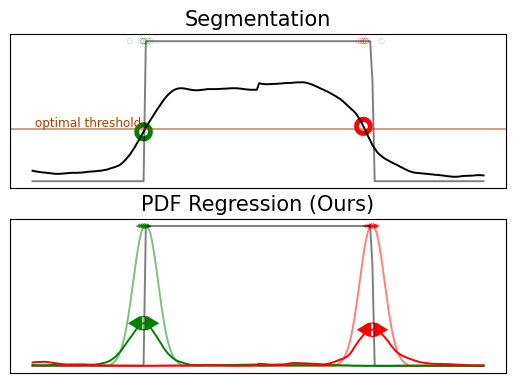

In [23]:
import pandas as pd
events = pd.read_csv('/kaggle/input/child-mind-institute-detect-sleep-states/train_events.csv')

# for epoch in range(1,11):
#     model.load_state_dict(torch.load(f'/kaggle/input/sleep-cleaned-data/models/models/model_f0_e{epoch}.pth'))
#     x,y,m,id = ds[0]
    
#     e = events.loc[events.series_id==id]
#     out = model(torch.unsqueeze(torch.tensor(x[0]),0)).detach().numpy()
    
# #     print(e)
#     o1,o2 = e.loc[e.event=='onset'].step[:2].astype(int)//10
#     w1,w2 = e.loc[e.event=='wakeup'].step[:2].astype(int)//10
    
#     y = np.concatenate([y[0][(o1-50):(o1+50)],y[0][(w1-50):(w1+50)],y[0][(o2-50):(o2+50)],y[0][(w2-50):(w2+50)]])
#     out = np.concatenate([out[0][(o1-50):(o1+50)],out[0][(w1-50):(w1+50)],out[0][(o2-50):(o2+50)],out[0][(w2-50):(w2+50)]])
#     plt.plot(y)
#     plt.plot(out)
#     plt.show()

from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.pyplot as plt

seg_p,reg_p = [], []
fig,ax = plt.subplots((2))
# g1,g2 = ax.plot([], color="red", lw=2),ax.plot([], color="red", lw=2)

def animate(epoch):
    global seg_p,reg_p
#     print(seg_p,reg_p)
    
    ax[0].clear()
    ax[1].clear()
    if epoch>0:
        reg_model.load_state_dict(torch.load(f'/kaggle/input/sleep-cleaned-data/regmodel/regmodel/model_f0_e{epoch}.pth'))
        seg_model.load_state_dict(torch.load(f'/kaggle/input/sleep-cleaned-data/segmodel/segmodel/model_f0_e{epoch}.pth'))
        
    reg_t,reg_x = np.zeros((200,2)), np.zeros((200,2))
    seg_t,seg_x = np.zeros((200)), np.zeros((200))
    
    for j in range(10):
        inp,reg_y,m,id = reg_ds[j]
        inp,seg_y,m,id = seg_ds[j]
        reg_y,seg_y = reg_y[0],seg_y[0][...,0]
        e = events.loc[events.series_id==id]
        
        inp = torch.unsqueeze(torch.tensor(inp[0]),0).float()
        if epoch>0:
            reg_out = reg_model(inp).detach().numpy()[0]
            seg_out = seg_model(inp).sigmoid().detach().numpy()[0][...,0]
        else:
            reg_out = np.zeros(reg_y.shape)
            seg_out = np.zeros(seg_y.shape)
            
        for i in range(len(e)//2):
            o = e.loc[e.event=='onset'].step.values[i]
            w = e.loc[e.event=='wakeup'].step.values[i]
            try:
                o,w = int(o)//10,int(w)//10
#                 print(o,w)
            except Exception as error:
#                 print(error)
                continue
            if len(reg_y[(o-50):(o+50)])==100 and len(reg_y[(w-50):(w+50)])==100:
                reg_t += np.concatenate([reg_y[(o-50):(o+50)],reg_y[(w-50):(w+50)]])
                reg_x += np.concatenate([reg_out[(o-50):(o+50)],reg_out[(w-50):(w+50)]])
                
                seg_t += np.concatenate([seg_y[(o-50):(o+50)],seg_y[(w-50):(w+50)]])
                seg_x += np.concatenate([seg_out[(o-50):(o+50)],seg_out[(w-50):(w+50)]])
        
#     o1,o2 = e.loc[e.event=='onset'].step[:2].astype(int)//10
#     w1,w2 = e.loc[e.event=='wakeup'].step[:2].astype(int)//10
    
#     y = np.concatenate([y[0][(o1-50):(o1+50)],y[0][(w1-50):(w1+50)],y[0][(o2-50):(o2+50)],y[0][(w2-50):(w2+50)]])
#     out = np.concatenate([out[0][(o1-50):(o1+50)],out[0][(w1-50):(w1+50)],out[0][(o2-50):(o2+50)],out[0][(w2-50):(w2+50)]])
    ax[0].set_xticks([])
    ax[0].set_yticks([])
#     ax[0].axis('off')
    ax[1].set_xticks([])
    ax[1].set_yticks([])
#     ax[1].axis('off')

    


    lines = []
    lines.append(ax[0].plot(seg_t,color = 'black',alpha=0.5))
    lines.append(ax[0].plot(seg_x,color = 'black',alpha=1))
    
    (cand1, cand2), (score1, score2), predictions= get_candidates(seg_x, 'seg1', max_distance = (15), day_length = 100, threshold = 20)
    if len(cand1)!=0:
        import matplotlib.patches
        score1,score2 = seg_x[cand1],seg_x[cand2]
        circle1 = matplotlib.patches.Ellipse((cand1, score1), 2, 2, color='g', lw=10, fill=False)
        circle2 = matplotlib.patches.Ellipse((cand2, score2), 2, 2, color='r', lw=10,fill=False)
        ax[0].add_patch(circle1)
        ax[0].add_patch(circle2)
        
        ax[0].axhline(20, color = orange_black[3], alpha=0.5)
#         ax[0].text(1, 11, f'optimal threshold', color = orange_black[3])
        ax[0].text(1, 21, f'optimal threshold', color = orange_black[3],fontsize='xx-small')
        
        for c1,c2 in seg_p:
            circle1 = matplotlib.patches.Ellipse((c1, np.max(seg_t)), 0.1, 0.1, color='g', lw=4,alpha=0.5, fill=True)
            circle2 = matplotlib.patches.Ellipse((c2, np.max(seg_t)), 0.1, 0.1, color='r', lw=4,alpha=0.5,fill=True)
            ax[0].add_patch(circle1)
            ax[0].add_patch(circle2)
        seg_p.append((cand1, cand2))
    
#     g3 = ax[1].plot(reg_t,color = ['g','r'],alpha=0.5)
#     g4 = ax[1].plot(reg_x,color = ['g','r'])
    lines.append(ax[1].plot(seg_t*np.max(reg_t)/np.max(seg_t),color = 'black',alpha=0.5))
    lines.append(ax[1].plot(reg_t[:,0],color = 'g',alpha=0.5))
    lines.append(ax[1].plot(reg_t[:,1],color = 'r',alpha=0.5))
    lines.append(ax[1].plot(reg_x[:,0],color = 'g',alpha=1))
    lines.append(ax[1].plot(reg_x[:,1],color = 'r',alpha=1))
    
#     print(find_peaks(reg_x[:,0], height = 0, distance = 10)[0])
    (cand1, cand2), (score1, score2), predictions = get_candidates(reg_x, 'gau', max_distance = (200), day_length = 100, threshold = 0.0)
    if len(cand1)!=0:
#         return lines
#         print(cand1,cand2)
        import matplotlib.patches
        circle1 = matplotlib.patches.Ellipse((cand1, score1), 2, 2, color='g', lw=10, fill=False)
        circle2 = matplotlib.patches.Ellipse((cand2, score2), 2, 2, color='r', lw=10,fill=False)
#         print(circle1)
        ax[1].add_patch(circle1)
        ax[1].add_patch(circle2)
        
        for c1,c2 in reg_p:
            circle1 = matplotlib.patches.Ellipse((c1, np.max(reg_t)), 0.1, 0.1, color='g', lw=4,alpha=0.5, fill=True)
            circle2 = matplotlib.patches.Ellipse((c2, np.max(reg_t)), 0.1, 0.1, color='r', lw=4,alpha=0.5,fill=True)
            ax[1].add_patch(circle1)
            ax[1].add_patch(circle2)
        reg_p.append((cand1, cand2))
    
    ax[0].title.set_text('Segmentation')
    ax[1].title.set_text('PDF Regression (Ours)')
    return lines


ani = FuncAnimation(fig, animate, interval=11, blit=False, repeat=True, frames=10)    
ani.save("PDFR.gif", dpi=300, writer=PillowWriter(fps=2))
plt.show()

In [24]:
# df = pd.read_csv('/kaggle/input/sleep-cleaned-data/Untitled spreadsheet - Sheet1.csv')

# df['% change in Depth.1'] = [np.nan,-12.5,-25,-25,-15]
# df['% change in # of shrimp.2'] = [np.nan,100,0,30,300]

In [25]:
# for i in df.columns:
#     try:
#         df[i] = df[i].str.split('%').apply(lambda x: x if x is np.nan else x[0]).astype(np.float32)
#     except Exception as e:
#         print(e)
#         pass
# df = df[df.columns[1:].tolist()]
# df

In [26]:
# for i in range(6):
#     print(df.values[:,i])
#     plt.plot(df.values[:,i])
# plt.legend(['control - percent change of shrimp',
#             'control - percent change of algae depth',
#             '0.5 - percent change of shrimp',
#             '0.5 - percent change of algae depth',
#             '1.0 - percent change of shrimp',
#             '1.0 - percent change of algae depth',
#            ])
# plt.show()